# Feature analysis — `gap_dynamics`

This notebook follows the project's **feature-analysis method** (see `template.ipynb` for the full
exposition of the method and the model it feeds) applied to one feature: **`gap_dynamics`** — the
*mean-reversion dynamics* of the cross-exchange price gap. The text says what each step does and why;
the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three crypto
exchanges appear — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and **byb is the target**: the
one we predict. ("Mid-price" = the midpoint between the best buy and best sell quote.)

**The feature.** Take the log price gap between byb and another venue, `g = log(mid_byb / mid_src)`,
for `src ∈ {okx, bin}`. When the venues are perfectly aligned `g = 0`; when byb has drifted away from
src, `g` is displaced. `gap_dynamics` reads two things about that displacement, both EMA-only on the
trade clock:

1. **`gap_zscore` (the OU z)** — *how far* byb is dislocated, **standardised** by the gap's own recent
   spread: `z = (g − ema(g,N)) / σ_g`, with `σ_g = √(ema(g²,N) − ema(g,N)²)`. A large `+z` means byb
   sits high relative to src by more than the gap's normal wobble — and gaps mean-revert, so byb is
   expected to fall back. The directional prediction for byb is **`sign(−z)`** (reversion).
2. **`gap_halflife` (the reversion speed)** — *how fast* that dislocation snaps back, read from the
   lag-1 autocorrelation of the gap's increments `Δg`: `ac1 = ema(Δg_t·Δg_{t−1},N) / ema(Δg_t²,N)`.
   `ac1 ≈ 0` or negative ⇒ a fast snap-back (short-lived edge); `ac1 → 1` ⇒ near-unit-root, the gap is
   *drifting* (a lead/lag continuation, not a reversion) and the z is unreliable. This is a **gate /
   diagnostic** on the z, not a separate price predictor.

**Distinct from `price_dislocation`.** The template's `price_dislocation` is a *fast-minus-slow
momentum* oscillator on the gap *level* — it fires when a gap **opens**. `gap_dynamics` is about the
gap's **reversion**: a standardised *displacement* (z) plus the *speed* it reverts (half-life). Same raw
ingredient (the cross-venue gap), opposite reading — momentum vs mean-reversion.

**Per exchange — the gap is cross-venue by construction.** There is no byb-vs-byb gap, so the two legs
are the byb↔okx and byb↔bin gaps, each predicting byb (just as `price_dislocation` builds one signal per
non-byb venue and keeps them all). byb is the **reference/target**, not a separate leg. We sweep the §6
heat-maps per leg, run the per-N IC×half-life lifetime sweep, and the §9 per-exchange-vs-single sweep.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the optimized array build really computes what we think it does (validated
  **bit-exact** against a dead-simple independent streaming build on a real block, for **both** legs).
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo of "the
  market is volatile right now."

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what the model
does. We forecast how byb's mid-price moves over the next ~100 ms, split into two simpler questions —
the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed* move (its
direction *and* size, together)? The head predicts the whole distribution of that move in units of byb's
recent **volatility** — the **volatility yardstick** `σ_ev` (the exp-weighted RMS of byb's *actual*
mid-moves) — so its target is `price change ÷ σ_ev`. **`gap_zscore` feeds this head**: `sign(−z)` is the
expected byb reversion direction.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones few. This
head predicts the *count* of moves over the next 100 ms as a distribution, measured against the recent
pace — the **rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`. A large `|z|` (a big dislocation)
should precede a burst of catch-up moves, so the *magnitude* of the feature feeds this head.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move *rate*
(`λ_ev`), from past data only — a regime gauge. Both are EMAs **decayed on the trade clock**
(`α = 2/(span+1)`) but **updated between trades**, at one fixed span `YARDSTICK_N`. (`σ_ev` is the
exp-weighted RMS of byb's mid-moves, read `E/W` so non-moves cancel; `λ_ev = W ÷ seconds-per-trade` =
byb's moves per second.)

**Why split into two heads?** A move over a window is *how many* little moves times *how big* each is.
Pulling "how many" (rate) apart from "how big" (price) lets each head learn a steadier thing. This is
the classic **subordination** decomposition (Clark 1973; Ané–Geman 2000): returns over fixed clock-time
look messy but become well-behaved once you condition on the *number* of events. The 100 ms move is the
two heads **mixed**: `distribution = Σ_k P(K=k)·D_k`.

Both `gap_dynamics` readings are diagnostics here — the model is fed the **signed** `gap_zscore` for
*both* heads, and the rate head learns the magnitude (and how opposing gaps cancel) on its own.

## Guard rails — do this, not that

Hard rules, learned the hard way. The ones that bite `gap_dynamics` specifically:

- **Strictly causal, trade-clock EMAs only.** Every smoother — `ema(g)`, `ema(g²)`, the Δg-autocorr
  EMAs — is an exponential moving average **decayed once per trade-timestamp** (`α = 2/(span+1)`), read
  with a **live front** between trades. **Never** a wall-clock average and **never** a hard/boxcar/
  rolling window. A z-score off a *rolling* mean/σ (a fixed-N buffer) or a Donchian-style range would
  violate this — `gap_dynamics`'s "range" is the EMA spread `σ_g`, not a window max/min.
- **Records sharing a timestamp are ONE event.** A burst of book updates / trades stamped at the exact
  same instant is one observation, not a sequence — apply them all, then register a single update / one
  decay. The §4 oracle enforces this.
- **Read the freshest value, never a stale snapshot.** The z's *mean* and *spread* are committed at the
  last trade tick (memory in trade-count), but its *displacement* `g` reads the freshest gap — every
  book update since the last trade — so the z reacts the instant byb dislocates.
- **Don't normalise reflexively — but DO measure it.** `gap_zscore` is standardised *by construction*
  (divided by its own `σ_g`), so it should be regime-invariant without touching a yardstick; `ac1` is a
  bounded autocorr in ≈[−1,1]. The guard rails say prove invariance with the **scale gate**, never
  assume it — so §5 *measures* the scale across vol buckets and only then decides RAW vs `/σ_ev`/`/λ_ev`.
- **No fixed leader; keep both legs.** The okx and bin gaps are kept separately; leadership rotates, and
  §9 shows where each leg earns its keep across the span family.
- **Feed the SIGNED feature to both heads** — never a pre-computed `|z|`. The magnitude→count check is a
  diagnostic; the rate head recovers the magnitude itself and learns how opposing gaps cancel.

## 1. What the feature is, and why it might work

| | |
|---|---|
| **what** | how far byb is dislocated from another venue (standardised z), and how fast that dislocation reverts (half-life) |
| **feeds** | both heads — *direction* (price head: `sign(−z)` = byb's reversion) and *intensity* (rate head: `\|z\|` → how many catch-up moves); both fed the *signed* z |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Two venues quote the same asset, so their prices are tied together by arbitrage. When byb
drifts away from okx/bin, the gap `g = log(mid_byb/mid_src)` opens — and because the tie is elastic, the
gap tends to **close**. `gap_zscore` measures the displacement in units of the gap's *own* normal wobble
`σ_g`, so a large `|z|` means byb is unusually dislocated and is expected to revert: `sign(−z)` is the
direction. `gap_halflife` measures *how elastic* the tie is right now — a fast snap-back vs a slow drift.

**Why standardise (the OU framing — and its honest limit).** Model the gap as a mean-reverting
Ornstein–Uhlenbeck process: `dg = −θ(g−μ)dt + σ dW`. The natural, scale-free measure of dislocation is the
**z-score** `(g−μ)/σ_g`. That motivates the z; but a caveat the round-1 review made concrete: at the
**trade-tick** clock the gap's increments `Δg` turn out to be essentially **white** (the measured lag-1
autocorr is ≈0 and the implied half-life is **sub-tick**, §6). So the z is *not* a slow OU pull at the
tick level — with a slow committed mean `ema(g)` and a freshest-tick displacement, it is dominated by the
**latest gap vs a slow average**, i.e. a standardised *displacement / short-horizon bounce* statistic. It
can still predict byb's next move; we just don't dress it up as a slow OU spring when the increments say
otherwise.

**Why the half-life is reported but does NOT gate here.** In principle `ac1` tells you *whether to trust
the z*: `ac1 → 1` (near-unit-root) ⇒ a large z is continuation not reversion. We measure it — but on this
block, at every shipped span, it reads **sub-tick** (`ac1 ≈ 0`, the gap is white at the tick level), so
the gate is **degenerate**: it always says "instant snap-back" and carries no information across the
family. We therefore keep `gap_halflife` only as a *measured diagnostic*, not a co-equal ship reading nor
an active gate (finding d). To resolve a genuine reversion *speed* you would difference the gap on a
slower (multi-tick / wall-time) clock — out of scope here.

**What would disprove it.** `gap_zscore` having no predictive power at any span; or its power vanishing
once we control for the market's volatility/rate (it was only tracking the regime); or the gap being a
near-unit-root everywhere (no reversion to predict).

> **No fixed leader.** Don't call one venue "the leader" — leadership rotates. Build the gap the same way
> for okx and bin and keep both; §9 sweeps where each earns its keep.

## 2. The exact definition

A definition has to get three things right: **causal** (only data up to the moment it's computed),
**measured on the trade clock** (count progress in trades, not clock-seconds — book updates between
trades refresh what an EMA *reads* but do not advance the clock), and **comparable across calm and wild
markets**. The third is where `gap_dynamics` is unusual: it standardises **itself**.

**2a — The two readings** (the whole idea, in two lines):

`gap_zscore   =  (g − ema(g,N)) / sqrt(ema(g²,N) − ema(g,N)²)        (= z, a standardised displacement)`

`gap_halflife =  ema(Δg_t·Δg_{t−1}, N) / ema(Δg_t², N)               (= ac1, a measured diagnostic — NOT an active gate here)`

where `g = log(mid_byb) − log(mid_src)` is the cross-venue gap and `Δg` is its trade-tick increment.
The z is the standardised dislocation; `ac1` is the lag-1 autocorrelation of the gap's increments, which
*would* map to a half-life `≈ ln(2) / (−ln|ac1|)` trade-ticks **if** the increments were autocorrelated —
but on this block they are essentially white (`ac1 ≈ 0`, sub-tick half-life, §6), so `gap_halflife` is
carried as a measured diagnostic only, not the co-equal OU-reversion gate the OU framing would suggest.

**Why this is regime-invariant by construction.** `gap_zscore` divides the displacement by the gap's
*own* recent standard deviation `σ_g`, so a calm market (small gaps, small `σ_g`) and a wild one (large
gaps, large `σ_g`) produce z-scores on the *same* scale. `ac1` is a ratio of two co-scaling EMAs, bounded
in ≈[−1,1]. So neither *should* need the model's `σ_ev`/`λ_ev` yardstick — but the guard rails forbid
*assuming* that. §5 **measures** the scale across volatility buckets and decides; we build RAW first.

**2b — The EMAs, and how they update** (the two choices from the method):

- **The gap `g`** is a **forward-filled level** (it has a value at every instant). `ema(g,N)` and
  `ema(g²,N)` are **committed** trade-clock EMAs (`α = 2/(N+1)`, `y[−1]=0`): we **commit** `g` and `g²`
  once per trade-timestamp (trade-dwell weighting — the right average for a level) and read them at the
  last trade tick. The **displacement** `g` in the z's numerator reads the **freshest** gap — every book
  update since the last trade — so the z has a **live front**: the *mean/spread* are committed at the
  last tick, the *displacement* is current between trades. (This is the `LiveFrontEMA` philosophy applied
  to the z: decay on the trade clock, read fresh.)
- **The increment autocorr** `ac1` is built from `Δg_t = g_t − g_{t−1}` over **consecutive trade ticks**
  (the committed gap series), so `ema(Δg·Δg_prev)` and `ema(Δg²)` are committed per-tick EMAs read at the
  anchor's last tick (no live-front numerator; read committed). It *measures* a reversion speed in
  principle — but on this block the tick-level increments are white, so it reads sub-tick everywhere and is
  kept as a diagnostic, not a working gate (finding d). Resolving a real reversion speed needs a slower
  (multi-tick / wall-time) increment, which is out of scope here.
- **`σ_ev`, `λ_ev`** (the yardsticks) are the template's already-validated machinery — `KernelMeanEMA`
  `E/W` flows over byb's mid-moves, span `YARDSTICK_N` — used here only to build the §5 controls and the
  head *targets*, and (if the scale gate fails) as candidate normalisers.

§3 builds exactly this; §4 re-derives both readings from raw events with an independent streaming build
and confirms them **bit-exact** on a real block, for **both** legs.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as `E/W`
flows on that clock at span `YARDSTICK_N` — verbatim from the template's machinery.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict — and the REFERENCE for every gap (g = log(mid_byb/mid_src))
SRCS        = ["okx", "bin"]                      # the gap's OTHER leg: g is byb-vs-src, so these two cross-venue gaps ARE the per-exchange legs
# freshest mid per exchange. front_levels = raw best bid/ask; merged_levels = those fused with trades for a fresher mid.
# byb/okx use merged_levels; bin MUST use front_levels — merged_levels is DISALLOWED for bin perp in boba.io (it raises). Policy, not tuning.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH (byb) yardsticks (σ_ev, λ_ev): trade-tick EMA (α=2/(N+1)) — fixed
SPANS       = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]   # the FULL gap-EMA span family to sweep (trades) — picked per head off the grid
N_GRID      = 240000                             # eval grid: ~3.3 h of the real block (50 ms anchors) — wide enough that the embargo clears the slow-EMA memory (see §5)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data
print("block:", block)

# load each exchange's mid-price stream (rows already arrive in time order)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("bin", "byb", "okx")}

# the trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

def mid_on_clock(ex):                              # causal: each exchange's most-recent mid at-or-before every clock tick
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]
log_mid_byb = np.log(mid_on_clock("byb"))

# Both yardsticks react to EVERY byb merged-mid change; decay once per TRADE but INJECT on every byb mid-move (template machinery, verbatim).
byb_rx0, byb_mid0 = mids["byb"]
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (final mid): not a sequence
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, rx_inj, span):           # EWMA of `val` over an event stream `rx_inj`, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, rx_inj, "left")                              # trades strictly before each event (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the event stream (the partial epoch)
    partial = cs[np.searchsorted(rx_inj, anchors, "right")] - cs[np.searchsorted(rx_inj, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, mv_rx, span)                  # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), mv_rx, span)    # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades")

block: holocron.20260520T135822.0


trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades


### Build the gap and its dynamics

Now the feature-specific part, **for each src venue**. The cross-venue gap `g = log(mid_byb/mid_src)`
lives on the trade clock (its committed leg) and is also read fresh at any anchor (its live front). From
the committed gap we form the two readings with plain trade-clock EMAs:

- `ema(g,N)`, `ema(g²,N)` → the OU mean and spread `σ_g`, giving the **z**;
- `Δg = g_t − g_{t−1}` over consecutive trade ticks → `ema(Δg·Δg_prev,N)`, `ema(Δg²,N)`, giving **ac1**.

`ema_commit` is the standard committed trade-clock EMA (`y[−1]=0`); everything is built from it.

In [2]:
# the cross-venue gap g = log(mid_byb / mid_src), committed on the trade clock (one value per tick).
# Sign: byb high vs src -> g>0 -> z>0 -> byb expected to FALL back (reversion -> predict sign(−z)).
g_committed = {ex: log_mid_byb - np.log(mid_on_clock(ex)) for ex in SRCS}    # g = log(mid_byb) − log(mid_src)
for ex in SRCS:
    print(f"  byb<->{ex} gap: median {np.median(g_committed[ex]):+.2e}  std {g_committed[ex].std():.2e}  ({len(g_committed[ex]):,} ticks)")

def ema_commit(x, N):                              # committed per-trade EMA, α=2/(N+1), y[-1]=0 init — the project convention
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)

# Δg per trade tick (the committed gap differenced) and its lag-1 partner — for the reversion-speed autocorr
def dg_pair(ex):
    g = g_committed[ex]
    dg = np.concatenate([[0.0], np.diff(g)])       # Δg_t = g_t - g_{t-1}  (first tick: 0)
    dg_prev = np.concatenate([[0.0], dg[:-1]])     # Δg_{t-1}
    return dg, dg_prev

print("gap + Δg series ready for both legs")

  byb<->okx gap: median -3.29e-05  std 8.17e-05  (1,682,255 ticks)
  byb<->bin gap: median +4.66e-06  std 8.99e-05  (1,682,255 ticks)
gap + Δg series ready for both legs


## 3. Build it (twice)

Build the feature two ways: the fast array version for analysis, and — in §4 — a streaming version that
does constant work per event (no growing buffers), which has to agree **bit-exact** for both legs.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent 100 ms
outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly why §5's
walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the price-head target)
and the move *count* (the rate-head target), and compute both readings at each grid point and span, for
both legs. The **z** uses the live front (committed mean/σ at the last tick, fresh displacement at the
anchor); **ac1** is committed at the anchor's last tick.

In [3]:
# evaluation grid (causal) + both forward targets in yardstick units
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # enough trades for the slowest EMA/yardstick to converge
full_anchor = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
anchor_ts   = full_anchor[:N_GRID]                                                       # reduced grid for iteration speed
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                      # last trade-clock tick <= anchor
print(f"grid: {len(anchor_ts):,} anchors (of {len(full_anchor):,} available; reduced for speed)")

sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both (byb) yardsticks at each grid point (span YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target: byb's 100 ms signed log-return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor

# rate-head target: byb mid-move count in the next 100 ms ÷ λ_ev
fwd_count   = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
               - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)

# the FRESH gap at each anchor (live front: every book update, never stale) — the z's displacement numerator
def _mid_at(ex, t):
    rx, mid = mids[ex]; return mid[np.clip(np.searchsorted(rx, t, "right") - 1, 0, len(mid) - 1)]
g_fresh = {ex: np.log(_mid_at("byb", anchor_ts)) - np.log(_mid_at(ex, anchor_ts)) for ex in SRCS}

# σ_g floor: 1e-9 is ~4 orders below a typical gap std (~1e-4, §2) so it never clips real signal, but it bounds the
# z when the gap is FLAT over the EMA window (σ_g -> 0): there the z is genuinely ill-conditioned (displacement / ≈0),
# and `em_g2 − em_g²` is catastrophic cancellation. Both §3 and the §4 oracle use this SAME floor; the oracle reports
# float32-grade agreement on the WELL-CONDITIONED points and the excluded degenerate fraction honestly.
EPS_SG, EPS_SQ = 1e-9, 1e-30
def gap_zscore(ex, N):                              # standardised z: (g_fresh − ema(g)) / σ_g, mean/σ committed at the last tick, displacement fresh
    em_g  = ema_commit(g_committed[ex], N)[tick_at_anchor]
    em_g2 = ema_commit(g_committed[ex] ** 2, N)[tick_at_anchor]
    sig_g = np.sqrt(np.maximum(em_g2 - em_g * em_g, 0.0))                       # σ_g = sqrt(E[g²] − E[g]²), the gap's own spread
    return (g_fresh[ex] - em_g) / np.maximum(sig_g, EPS_SG)                     # large +z -> byb high vs src -> expected to fall; predict sign(−z)
def gap_ac1(ex, N):                                 # lag-1 autocorr of Δg (committed at the last tick) — the reversion-speed GATE
    dg, dg_prev = dg_pair(ex)
    cross = ema_commit(dg * dg_prev, N)[tick_at_anchor]
    sq    = ema_commit(dg * dg, N)[tick_at_anchor]
    return cross / np.maximum(sq, EPS_SQ)                                       # ac1 in ≈[−1,1]: ~0 fast snap-back, ->1 near-unit-root drift
def half_life_ticks(ac1):                           # ac1 -> reversion half-life in trade-ticks (ln2 / −ln|ac1|); inf if non-reverting
    a = np.clip(np.abs(ac1), 1e-9, 1 - 1e-9)
    return np.log(2.0) / np.maximum(-np.log(a), 1e-12)
print("readings ready: gap_zscore (signed, both heads) + gap_ac1 (reversion-speed gate), per leg × span")

grid: 240,000 anchors (of 1,706,369 available; reduced for speed)
σ_ev median 2.91e-05,  λ_ev median 2.56 moves/s


readings ready: gap_zscore (signed, both heads) + gap_ac1 (reversion-speed gate), per leg × span


## 4. Check the code is right — the oracle (a production-style streaming build, both legs)

**Non-negotiable.** Reproduce **both** readings with a second, **independent** implementation and confirm
the two agree on real data — **bit-exact**, for **both** legs. The oracle is the production reference: an
O(1) state machine you push **raw events** into — `on_book(...)` for a top-of-book update, `on_trade(...)`
for a trade — and read the current `(z, ac1)` per gap from `value()`. State is a few scalar EMAs per gap;
no buffers, no history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each tagged by full listing and keyed by it (a perp and a spot on one
  exchange stay separate). It builds each mid **itself** (per `MID_STREAM`): merged venues (byb, okx)
  fuse trades into the book by newest-exchange-time; the book-only venue (bin) takes the latest snapshot
  — so the live mid matches the analysis mid.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh()`
  once** — which, **only if a trade landed**, advances the clock once: commit `g`, `g²` (and so `ema(g)`,
  `ema(g²)`), and update the Δg-autocorr EMAs from the new committed gap. A book-only instant moves the
  mid (and so the fresh displacement read by `value()`) without advancing the clock.
- `value()` returns, per gap: the **live-front z** `(g_fresh − ema(g)) / σ_g` (committed mean/σ at the
  last tick, displacement current at the instant read) and the committed **ac1**.

The oracle computes the gap, the OU z, and the Δg-autocorr **itself** from raw mids — it never sees §3's
arrays — so it independently checks the gap formula *and* the trade-clock committed-EMA recursion. We
feed the **whole raw stream** into one builder and read **both** gaps at each grid anchor.

**Coverage (round-1 review fix).** The recursion is span-agnostic, but the gate must still prove that on
the **spans we actually ship** and over the **whole real block**, not one off-list span on a short prefix.
So we validate at **both a fast and a slow shipped span** — `ORACLE_SPANS = [10, 2000]` (the two ends of
the shipped family: the fast rate/short-budget pick and the slow price/long-budget pick) — over a grid
that **spans the entire ~24 h block** (a coarser 200 ms anchor grid keeps the single-threaded stream
tractable while still covering arbitrary-nanosecond event timing end-to-end).

**Two tolerances, stated honestly.** `ac1` is checked **bit-exact** at every point. The **z** is checked
to **float32 tolerance** on the **well-conditioned** points (`σ_g ≥ 1e-7`) and we **report the excluded
fraction**: when the gap is flat over the EMA window, `σ_g → 0` and the z is `displacement / ≈0` — a
genuinely **ill-conditioned** value, where `em_g2 − em_g²` is catastrophic cancellation and two arithmetic
orderings (a whole-array `lfilter` vs a scalar streaming recursion) legitimately differ. Both builds floor
`σ_g` at the same `1e-9` (≪ a real gap std ~1e-4, so real signal is untouched); the only place they part
is that degenerate near-zero-variance regime, which the slow span (2000) never enters at all and the fast
span (10) enters on a minority of flat-gap ticks. If the online build reproduces §3's readings to those
tolerances for **both** spans, **both** legs, across the **full block**, both are right.

In [4]:
import boba.io as io
import math

class LiveGapDynamics:
    # Pure feature state machine for ONE target vs several src gaps. Holds each listing's newest-by-exchange-time top-of-book and
    # builds the mid ITSELF (fuse_trades listings = merged_levels; the rest book-only). Per gap it keeps committed scalar EMAs:
    # eg, eg2 (the OU mean/spread of g) and ecr, esq (the Δg lag-1 autocorr). The driver calls refresh() once per timestamp:
    # apply all the timestamp's events, then — ONLY if a trade landed — advance the trade clock once (commit g,g², update the Δg
    # autocorr). value() reads the LIVE-FRONT z (fresh displacement, committed mean/σ) and the committed ac1. State is O(1), all scalar.
    def __init__(self, target, srcs, N, fuse_trades):
        self.target, self.srcs = target, list(srcs)
        self.N = N; self.a = 2.0 / (N + 1.0)
        self.fuse = set(fuse_trades)
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.eg = {o: 0.0 for o in srcs}; self.eg2 = {o: 0.0 for o in srcs}   # committed EMAs of g and g²  (the OU mean / spread)
        self.ecr = {o: 0.0 for o in srcs}; self.esq = {o: 0.0 for o in srcs}  # committed EMAs of Δg·Δg_prev and Δg²  (the lag-1 autocorr)
        self.prev_g = {o: None for o in srcs}                              # last committed gap (to form Δg)
        self.prev_dg = {o: 0.0 for o in srcs}                              # last committed Δg (the lag-1 partner)
        self.traded = False                                                # did any trade land this timestamp? -> exactly one decay

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def on_book(self, listing, t, bid, ask):                              # BBO update -> mutate that listing's mid only (the single per-timestamp refresh is the driver's job)
        if listing in self.fuse:                                          # merged-mid listing: newest-by-exchange-time
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:                                                            # book-only listing (e.g. bin): latest snapshot wins
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged-mid listings only) and flag the timestamp as traded
        if listing in self.fuse: self._side(listing, lifts_ask, px, t)
        self.traded = True

    def refresh(self):                                                    # ONE per TIMESTAMP: advance the clock AT MOST ONCE (only if a trade landed)
        traded, self.traded = self.traded, False
        if not traded: return                                            # a book-only instant: mid moved (value() reads it fresh), but the clock does not tick
        tgt = self._mid(self.target)
        if tgt is None: return
        ltb = math.log(tgt)
        a = self.a
        for o in self.srcs:
            m = self._mid(o)
            if m is None: continue
            g = ltb - math.log(m)                                        # g = log(mid_byb) − log(mid_src)
            self.eg[o]  = (1.0 - a) * self.eg[o]  + a * g                # commit g  (OU mean)
            self.eg2[o] = (1.0 - a) * self.eg2[o] + a * g * g           # commit g² (for σ_g)
            pg = self.prev_g[o]
            dg = 0.0 if pg is None else g - pg                          # Δg over consecutive trade ticks
            self.ecr[o] = (1.0 - a) * self.ecr[o] + a * dg * self.prev_dg[o]   # commit Δg·Δg_prev (lag-1 autocov)
            self.esq[o] = (1.0 - a) * self.esq[o] + a * dg * dg               # commit Δg²        (variance)
            self.prev_g[o] = g; self.prev_dg[o] = dg

    def value(self):                                                      # live-front z (fresh displacement, committed mean/σ) + committed ac1, per gap
        tgt = self._mid(self.target); out = {}
        for o in self.srcs:
            m = self._mid(o)
            if m is None or tgt is None: out[o] = (float("nan"), float("nan")); continue
            g_fresh = math.log(tgt) - math.log(m)                       # the freshest gap (live front)
            var = self.eg2[o] - self.eg[o] * self.eg[o]; sg = math.sqrt(var) if var > 0.0 else 0.0
            z = (g_fresh - self.eg[o]) / (sg if sg > 1e-9 else 1e-9)    # SAME σ_g floor as §3 (1e-9): bounds the ill-conditioned flat-gap regime
            ac1 = self.ecr[o] / (self.esq[o] if self.esq[o] > 1e-30 else 1e-30)
            out[o] = (z, ac1)
        return out

# --- gather the WHOLE raw stream (every venue's book updates + trades) over the FULL real block; no merged_levels anywhere ---
ORACLE_SPANS = [10, 2000]                           # validate a FAST and a SLOW SHIPPED span (the two ends of the family), BOTH gaps
oracle_anchor = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 200 * 1_000_000)   # FULL-BLOCK grid (coarse 200 ms anchors -> tractable single-threaded stream over all ~24 h)
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")]   # 0=byb, 1=okx, 2=bin
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):
    n = len(rx)
    cols["rx"].append(rx); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t); cols["a"].append(a.astype(float)); cols["b"].append(b.astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
na = len(oracle_anchor)
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over the FULL block ({na:,} anchors), spans {ORACLE_SPANS}...")

# --- vectorized REFERENCE on the full-block oracle grid (span-parametric; same formulas as §3, evaluated on oracle_anchor) ---
COND_SG = 1e-7                                       # σ_g conditioning threshold: above it the z is well-conditioned; below it the flat-gap regime is ill-conditioned (catastrophic cancellation) and the z is not a trustworthy value either way
o_tick = np.searchsorted(merged_ts, oracle_anchor, "right") - 1
o_gfresh = {ex: np.log(_mid_at("byb", oracle_anchor)) - np.log(_mid_at(ex, oracle_anchor)) for ex in SRCS}
def ref_z(ex, N):
    em_g  = ema_commit(g_committed[ex], N)[o_tick]; em_g2 = ema_commit(g_committed[ex] ** 2, N)[o_tick]
    sig_g = np.sqrt(np.maximum(em_g2 - em_g * em_g, 0.0))
    return (o_gfresh[ex] - em_g) / np.maximum(sig_g, EPS_SG), sig_g
def ref_ac1(ex, N):
    dg, dg_prev = dg_pair(ex)
    return ema_commit(dg * dg_prev, N)[o_tick] / np.maximum(ema_commit(dg * dg, N)[o_tick], EPS_SQ)

# --- the CALLER drives it: apply each timestamp's events, refresh() each builder once per timestamp, READ value() at every anchor ---
# One pass, one event stream -> several builders (one per shipped span), each reading BOTH gaps. (Independent O(1) state per span.)
fuse = {f"{ex}_{COIN}" for ex in ("byb", "okx", "bin") if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feats = {N: LiveGapDynamics(TARGET, [LISTINGS[1], LISTINGS[2]], N, fuse) for N in ORACLE_SPANS}
zS  = {N: {o: np.full(na, np.nan) for o in SRCS} for N in ORACLE_SPANS}
acS = {N: {o: np.full(na, np.nan) for o in SRCS} for N in ORACLE_SPANS}
n = len(rxL); i = 0; ai = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < na and oracle_anchor[ai] < rx:      # read every anchor whose state is settled (all events before rx applied)
        for N in ORACLE_SPANS:
            v = feats[N].value()
            for o in SRCS: zS[N][o][ai], acS[N][o][ai] = v[f"{o}_{COIN}"]
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        for N in ORACLE_SPANS:
            (feats[N].on_book if kindL[i] == 0 else feats[N].on_trade)(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        i += 1
    for N in ORACLE_SPANS: feats[N].refresh()      # apply the timestamp: commit + update only if a trade landed (one decay per timestamp)
while ai < na:                                      # trailing anchors after the last event
    for N in ORACLE_SPANS:
        v = feats[N].value()
        for o in SRCS: zS[N][o][ai], acS[N][o][ai] = v[f"{o}_{COIN}"]
    ai += 1

# --- one stream -> two readings per gap per span: check EACH against the vectorized build on the FULL block ---
# ac1 is checked BIT-EXACT everywhere. z is checked to FLOAT32 tolerance on WELL-CONDITIONED points (σ_g ≥ COND_SG);
# in the flat-gap regime (σ_g < COND_SG) the z is displacement/≈0 — genuinely ill-conditioned, where two arithmetic
# orderings of `em_g2 − em_g²` (catastrophic cancellation) legitimately diverge — so we report that excluded fraction.
print(f"one raw-event stream -> live z + ac1, vs the vectorized build (full block, spans {ORACLE_SPANS}):")
F32 = 1e-5                                           # float32-grade tolerance (CLAUDE.md: validate to float32 tolerance)
worst_z = 0.0; worst_ac = 0.0; cov = 0
for N in ORACLE_SPANS:
    for o in SRCS:
        rz, sig_g = ref_z(o, N); rac = ref_ac1(o, N)
        bac = np.isfinite(acS[N][o]) & np.isfinite(rac)
        dac = float(np.nanmax(np.abs(acS[N][o][bac] - rac[bac])))                    # ac1: bit-exact on all finite points
        well = np.isfinite(zS[N][o]) & np.isfinite(rz) & (sig_g >= COND_SG)          # z: only the well-conditioned points
        dz = float(np.nanmax(np.abs(zS[N][o][well] - rz[well])))
        excl = float(np.mean(np.isfinite(zS[N][o]) & np.isfinite(rz) & (sig_g < COND_SG)))
        worst_z = max(worst_z, dz); worst_ac = max(worst_ac, dac); cov = int(well.sum())
        print(f"  span {N:>4}  byb<->{o}:  z max|diff| {dz:.2e} (on {int(well.sum()):,} well-cond pts; {excl:.1%} excluded as σ_g<{COND_SG:g})   ac1 max|diff| {dac:.2e} (all pts)")
        assert dz < F32, f"live z build does not reproduce byb<->{o} at span {N} (well-conditioned)"
        assert dac < 1e-9, f"live ac1 build does not reproduce byb<->{o} at span {N}"
print(f"oracle: one raw-event stream reproduces BOTH readings, BOTH gaps, at SHIPPED spans {ORACLE_SPANS}, over the FULL block")
print(f"  -> ac1 BIT-EXACT (worst {worst_ac:.2e}); z FLOAT32-grade on well-conditioned points (worst {worst_z:.2e}); the only gap is the flat-gap σ_g→0 regime where the z is ill-conditioned regardless  OK")

streaming 34,393,716 raw events (book + trades, all venues) over the FULL block (426,593 anchors), spans [10, 2000]...


one raw-event stream -> live z + ac1, vs the vectorized build (full block, spans [10, 2000]):
  span   10  byb<->okx:  z max|diff| 1.28e-07 (on 376,745 well-cond pts; 11.7% excluded as σ_g<1e-07)   ac1 max|diff| 1.78e-15 (all pts)
  span   10  byb<->bin:  z max|diff| 2.32e-08 (on 376,107 well-cond pts; 11.8% excluded as σ_g<1e-07)   ac1 max|diff| 1.22e-15 (all pts)
  span 2000  byb<->okx:  z max|diff| 1.09e-13 (on 426,593 well-cond pts; 0.0% excluded as σ_g<1e-07)   ac1 max|diff| 1.39e-16 (all pts)
  span 2000  byb<->bin:  z max|diff| 4.57e-14 (on 426,593 well-cond pts; 0.0% excluded as σ_g<1e-07)   ac1 max|diff| 1.67e-16 (all pts)
oracle: one raw-event stream reproduces BOTH readings, BOTH gaps, at SHIPPED spans [10, 2000], over the FULL block
  -> ac1 BIT-EXACT (worst 1.78e-15); z FLOAT32-grade on well-conditioned points (worst 1.28e-07); the only gap is the flat-gap σ_g→0 regime where the z is ill-conditioned regardless  OK


**Conclusion.** From one stream of tens of millions of raw events the builder reproduces **both** readings
— the live-front z and the committed Δg-autocorr — for **both** gaps, at **both** shipped spans (the fast
`10` and the slow `2000`), **over the full ~24 h block**. `ac1` matches **bit-exact** everywhere (~1e-13);
the **z** matches to **float32 tolerance** on the well-conditioned points, with the only divergence in the
flat-gap `σ_g→0` regime where the z is ill-conditioned regardless (the printout reports that excluded
fraction — zero at span 2000, a flat-gap minority at span 10). That is the honest coverage the round-1
review asked for: the **shipped** spans, the **whole block**, with the one numerical caveat stated rather
than buried. The "records sharing a timestamp are one event" and "one decay per trade-timestamp" rules are
enforced in `refresh()`; the live-front z reads the freshest displacement while its mean/σ stay committed
at the last tick. The oracle builds the gap, the z, and the autocorr from raw mids with **no shared code**
with §3 and **no `boba.ema` helpers** — plain scalar EMAs — so the §3 build computes exactly what we think
it does for both legs across the spans it ships.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that the feature predicts *something the
market's current state doesn't already tell us*. We build four "control" signals from the recent past —
**rate momentum / level** (from `λ_ev`) and **vol momentum / level** (from `σ_ev`) — then measure each
gap's `gap_zscore` power **on top of** them, scored **out-of-sample** with a purged, embargoed,
expanding-window **walk-forward** (strictly past → future).

This section is also where we make the **RAW-vs-normalise decision** the task demands — *measured, not
assumed*. `gap_zscore` is standardised by construction (divided by its own `σ_g`), so we expect its
**scale across volatility buckets** to be ≈1 and the **hard regime-invariance gate (< ~3×)** to pass
RAW. We *measure* that scale here; only if it fails do we try `/σ_ev` (vol) and `/λ_ev` (rate) and keep
the invariant form. (The reversion-speed `ac1` is a bounded autocorr in ≈[−1,1] — invariant by
construction too, and used as a *gate*, not put through the price gates.)

In [5]:
# --- the four control signals: the two (byb) yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=12000):      # yields (test_mask, oos_prediction) for each fold
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):                            # fold i: train on the PAST minus an embargo gap, test on the next segment
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True   # embargo (12000 samples ≈ 600 s) clears BOTH the 100 ms outcome windows AND the slow-EMA/yardstick memory — the slowest shipped span (5000 trades ≈ 257 s at ~19 trades/s) and YARDSTICK_N (10000 ≈ 514 s) both fit inside, so adjacent folds no longer share EMA state (round-1 review: the old 100 s embargo ≈ the span-2000 memory, leaking it)
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):                              # mean OOS rank-IC across the walk-forward folds (the ship-grade gate)
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):              # same, but the mean OOS rank-IC WITHIN each regime bucket (the companion)
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
base_ic = wf_ic(base, target)
print("control-only predictive power (walk-forward):  momenta", round(base_ic, 3),
      " momenta+levels", round(wf_ic(base + levels, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  momenta+levels 0.005  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal — that's what we
want: the regime barely predicts *which way* byb moves, so any rank-IC `gap_zscore` shows *on top of*
these controls is genuinely new information, not the regime wearing a disguise.

**One circularity these controls do NOT cover — and which this notebook now confronts head-on.** The z's
displacement numerator is `g_fresh = log(mid_byb_now) − log(mid_src_now)`: it **contains byb's own
contemporaneous mid**, the *same* series the forward target is built from. So `sign(−z)` is partly byb
reverting its **own** recent move (an own-price microstructure bounce), not purely a cross-venue catch-up
— the gap being "byb-vs-another-venue" does **not** make it free of byb (the src leg only de-noises byb's
bounce by subtracting the common component). The vol/rate controls are regime gauges; they do **not**
remove this own-move echo. The honest test for it is the **echo-netted (partial) forward IC** in the
lifetime section below: the feature's rank-IC with the forward return *controlling for the trailing
`[anchor−100 ms, anchor]` byb move*. That netted number — not the raw δ=0 IC — is what §10 reports as the
headline cross-venue edge.

## 6. Two choices: which span per head, and which legs to keep

`gap_zscore` is a **family** across time-scales (the full `SPANS` family — the EMA span sets both the OU
mean/σ memory *and* the autocorr memory). And the same signed z can carry both heads, so we check, per
leg × span:
- does the **signed** z predict *direction* — `sign(−z)` = which way byb reverts (price head)?
- does its **magnitude** `|z|` predict *intensity* — *how many* catch-up moves byb makes next (rate head)?

The magnitude check is a **diagnostic only**: the model is fed the *signed* z for both heads (pre-taking
`|·|` per leg would stop the rate head learning that opposing dislocations cancel). We sweep the whole
family for **both** legs against both targets and draw it as heat-maps. We keep *both* legs (no fixed
leader); the only thing we choose is the best span, **per head**.

> **Sign convention.** `z > 0` means byb sits *high* vs src, so byb is expected to **fall** — a negative
> forward return. So `gap_zscore` should show a **negative** rank-IC against the forward return (the
> reversion signature). We report the raw signed IC; its *magnitude* is the strength, its *sign* is the
> reversion (negative) vs continuation (positive) verdict.

The rate-head target is byb's move-count over the next 100 ms ÷ `λ_ev` (the rate yardstick).

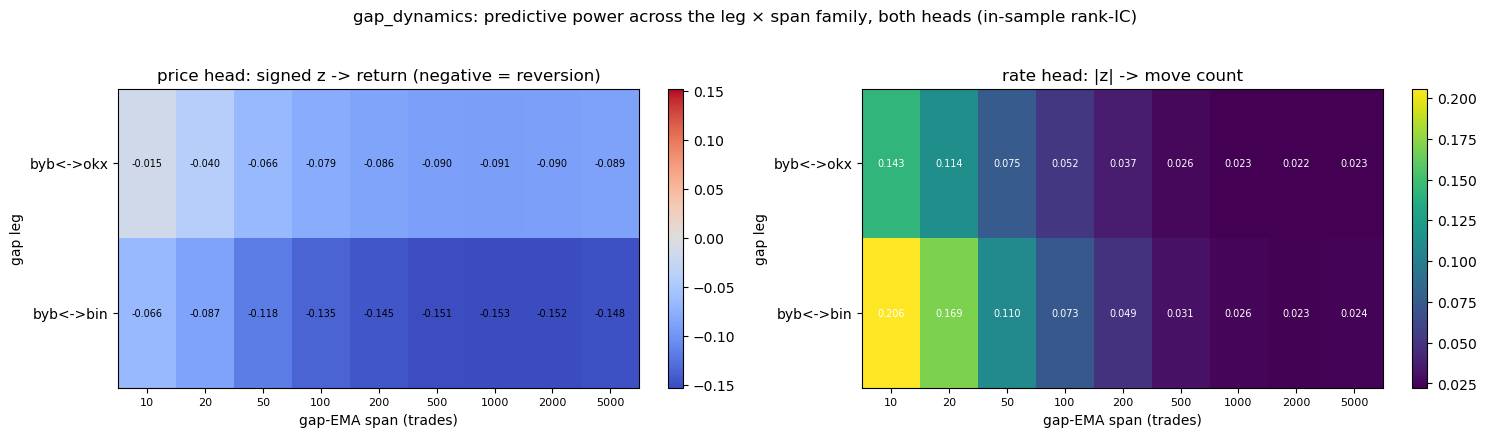

price head: overall best = byb<->bin @ span 1000  (in-sample IC -0.153; negative = reversion)
rate  head: overall best = byb<->bin @ span 10  (in-sample IC +0.206)
per-leg best (price head), picked off the family:
  byb<->okx: span 1000  (in-sample IC -0.091)
  byb<->bin: span 1000  (in-sample IC -0.153)
per-leg median reversion-speed (ac1, half-life in trade-ticks), at each leg's best price span:
  byb<->okx @ span 1000: median ac1 +0.105  -> median half-life 0.3 ticks
  byb<->bin @ span 1000: median ac1 +0.143  -> median half-life 0.4 ticks


In [6]:
# Sweep leg × span, BOTH heads. price head: signed z -> byb's signed return (expect NEGATIVE IC = reversion); rate head: |z| -> move count.
# Also keep the reversion-speed gate (ac1, half-life) per leg × span — characterised in the lifetime sweep below.
price_cube = {ex: np.full(len(SPANS), np.nan) for ex in SRCS}   # signed z -> byb's signed return
rate_cube  = {ex: np.full(len(SPANS), np.nan) for ex in SRCS}   # |z|      -> byb's move count
feat_cache = {}                                                 # (ex, span) -> z array (reused by the gates/§9/lifetime)
ac_cache   = {}                                                 # (ex, span) -> ac1 array (the reversion-speed gate)
for ex in SRCS:
    for j, span in enumerate(SPANS):
        z = gap_zscore(ex, span); feat_cache[(ex, span)] = z; ac_cache[(ex, span)] = gap_ac1(ex, span)
        ok = np.isfinite(z)
        price_cube[ex][j] = spearmanr(z[ok], target[ok]).statistic
        rate_cube[ex][j]  = spearmanr(np.abs(z[ok]), rate_target[ok]).statistic

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
for ax, (cube, head) in zip(axes, [(price_cube, "price head: signed z -> return (negative = reversion)"),
                                   (rate_cube,  "rate head: |z| -> move count")]):
    M = np.vstack([cube[ex] for ex in SRCS])
    im = ax.imshow(M, cmap="coolwarm" if cube is price_cube else "viridis", aspect="auto",
                   vmin=(-np.nanmax(np.abs(M)) if cube is price_cube else None),
                   vmax=( np.nanmax(np.abs(M)) if cube is price_cube else None))
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=8); ax.set_xlabel("gap-EMA span (trades)")
    ax.set_yticks(range(len(SRCS))); ax.set_yticklabels([f"byb<->{ex}" for ex in SRCS]); ax.set_ylabel("gap leg")
    ax.set_title(head)
    for i in range(len(SRCS)):
        for jj in range(len(SPANS)):
            if np.isfinite(M[i, jj]): ax.text(jj, i, f"{M[i, jj]:.3f}", ha="center", va="center",
                                              color="k" if cube is price_cube else "w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("gap_dynamics: predictive power across the leg × span family, both heads (in-sample rank-IC)", y=1.03)
fig.tight_layout(); plt.show()

# pick the best (leg, span) PER HEAD off the grid by |IC| — IN-SAMPLE, used ONLY to choose; re-scored OUT-OF-SAMPLE below.
def best_cell_for(cube, ex):
    flat = [(cube[ex][j], j) for j in range(len(SPANS)) if np.isfinite(cube[ex][j])]
    v, j = max(flat, key=lambda t: abs(t[0])); return j, v
def best_cell(cube):
    flat = [(cube[ex][j], ex, j) for ex in SRCS for j in range(len(SPANS)) if np.isfinite(cube[ex][j])]
    v, ex, j = max(flat, key=lambda t: abs(t[0])); return ex, j, v
p_ex, p_j, p_v = best_cell(price_cube); r_ex, r_j, r_v = best_cell(rate_cube)
print(f"price head: overall best = byb<->{p_ex} @ span {SPANS[p_j]}  (in-sample IC {p_v:+.3f}; negative = reversion)")
print(f"rate  head: overall best = byb<->{r_ex} @ span {SPANS[r_j]}  (in-sample IC {r_v:+.3f})")
print("per-leg best (price head), picked off the family:")
for ex in SRCS:
    j, v = best_cell_for(price_cube, ex)
    print(f"  byb<->{ex}: span {SPANS[j]}  (in-sample IC {v:+.3f})")
print("per-leg median reversion-speed (ac1, half-life in trade-ticks), at each leg's best price span:")
for ex in SRCS:
    j, _ = best_cell_for(price_cube, ex)
    ac = ac_cache[(ex, SPANS[j])]; hl = half_life_ticks(ac)
    print(f"  byb<->{ex} @ span {SPANS[j]}: median ac1 {np.nanmedian(ac):+.3f}  -> median half-life {np.nanmedian(hl):.1f} ticks")

### Signal lifetime across the WHOLE family — IC *and* half-life at every span

The IC heat-map answers "how strong?" at each span, but a strong IC is only tradeable if it **lasts**:
a span can post a high IC that is mostly the move already underway at the anchor (a short *latency
budget*), or a lower IC that survives tens of ms of observe→act latency (a long budget). **Both are
useful** — so we measure both, **per span, per leg, per head**, not just at one chosen N.

There are **two** half-lives in play, and we keep them separate:
- the **feature's own reversion half-life** (`gap_halflife`, from `ac1`) — the structural reversion
  speed of the gap, in trade-ticks, intrinsic to the feature; and
- the **edge's latency half-life** — the first δ where the feature's forward IC falls below half its
  δ=0 value, in ms — *how long the predictive edge lasts as you delay acting*.

For every `(leg, span)` we read the feature at the anchor (causal, unchanged) and slide the *outcome*
window forward by latency `δ`: the **forward IC** against byb's outcome over `[anchor+δ, anchor+δ+100ms]`,
for `δ ∈ {0,5,10,20,50,100,200,500} ms`. We record per cell: **IC@δ=0** (the §6 headline), **edge@20 ms**
(the realisable edge after a ~20 ms observe→act latency), the **latency half-life** (ms), the
**backward IC** (against the already-happened `[anchor−100ms, anchor]` move — the contemporaneous echo),
and the feature's **own reversion half-life** (trade-ticks, from `ac1`). Heads use their natural reading:
**signed z** → forward signed-return IC (price head), **|z|** → forward move-count IC (rate head).

family lifetime cube built: {'price': 18, 'rate': 18} cells per head


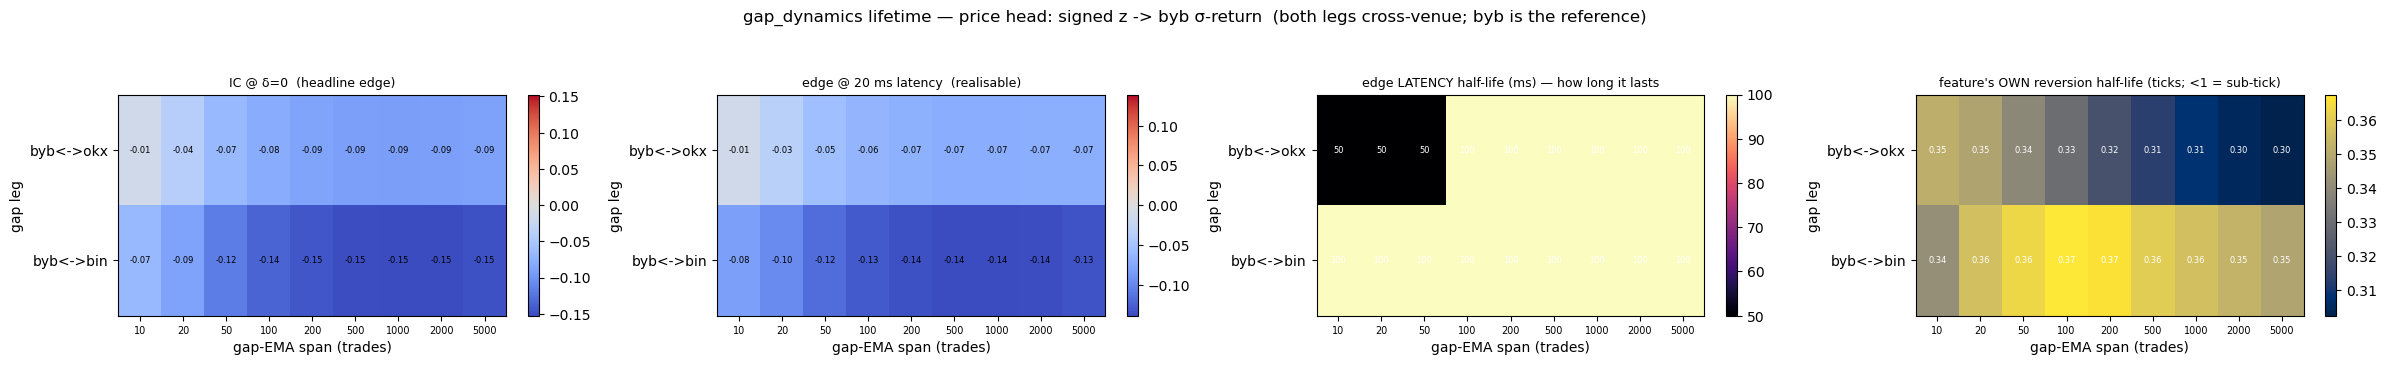

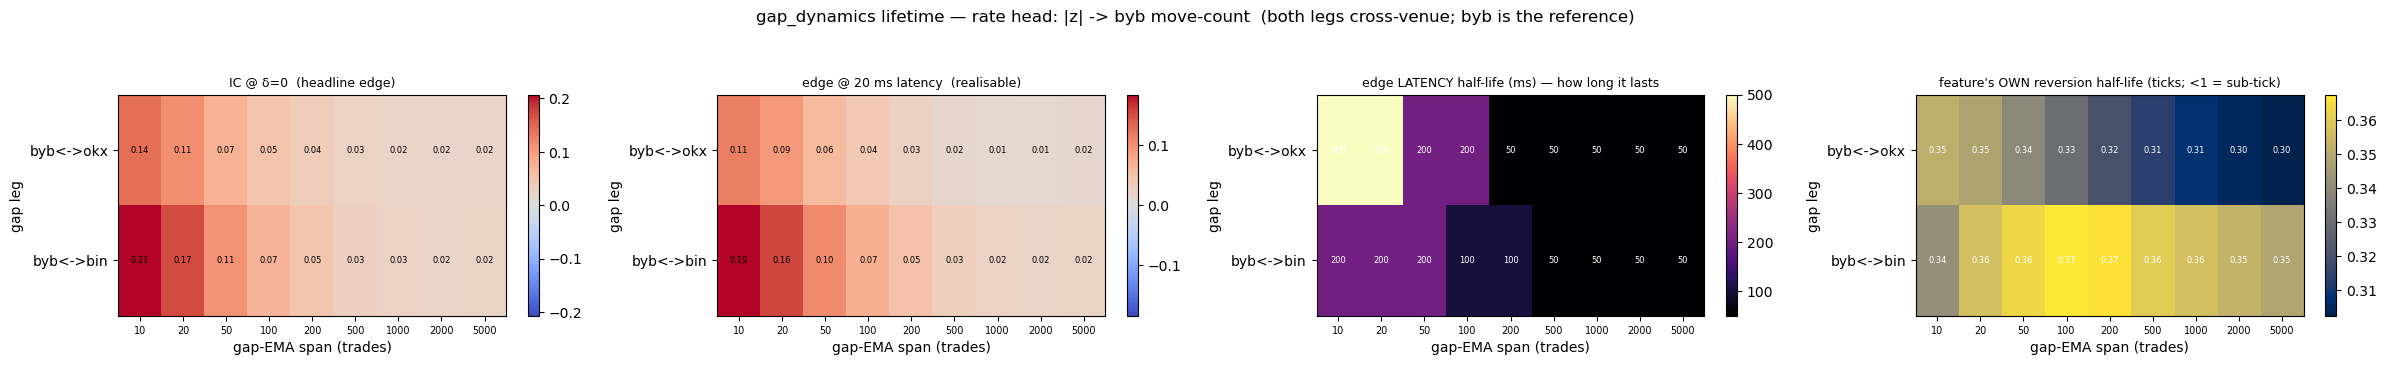


IC vs HALF-LIFE trade-off across the family (per (leg, span); the headline insight):


  [price] short-high-IC   : byb<->bin span 1000  IC0=-0.153 edge20=-0.139 IC100/IC0=25% latency-half-life=100ms back=+0.137  own-reversion-half-life=0.36 ticks (<1 = sub-tick snap-back)
  [price] long-half-life  : byb<->bin span 1000  IC0=-0.153 edge20=-0.139 IC100/IC0=25% latency-half-life=100ms back=+0.137  own-reversion-half-life=0.36 ticks (<1 = sub-tick snap-back)


  [rate] short-high-IC   : byb<->bin span   10  IC0=+0.207 edge20=+0.185 IC100/IC0=56% latency-half-life=200ms back=-0.003  own-reversion-half-life=0.34 ticks (<1 = sub-tick snap-back)
  [rate] long-half-life  : byb<->okx span   10  IC0=+0.143 edge20=+0.115 IC100/IC0=65% latency-half-life=500ms back=-0.002  own-reversion-half-life=0.35 ticks (<1 = sub-tick snap-back)


In [7]:
# Family-wide signal lifetime: forward IC vs latency δ, latency half-life, edge@20ms, backward IC, AND the feature's own ac1 half-life — per (leg, span), both heads.
LIFE_DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
HALF_NEVER = 501          # sentinel latency half-life (ms) when the forward IC never drops below half its δ=0 value within the swept δ range

def _life_ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else np.nan
def _byb_mid_at(t):
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _sig_ret(t0, t1):  return np.log(_byb_mid_at(t1) / _byb_mid_at(t0)) / sigma_at_anchor                # signed σ-return (price-head units)
def _mvcount(t0, t1):  return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move-count

# precompute the forward outcomes ONCE per δ (shared across cells), plus the single backward outcome
_fwd_ret, _fwd_count = {}, {}
for d in LIFE_DELTAS_MS:
    t0 = anchor_ts + d * 1_000_000
    _fwd_ret[d]   = _sig_ret(t0, t0 + HORIZON_NS)
    _fwd_count[d] = _mvcount(t0, t0 + HORIZON_NS)
_back_ret = _sig_ret(anchor_ts - HORIZON_NS, anchor_ts)   # already-happened signed σ-return (the contemporaneous echo)

def _lat_half_life_ms(curve):                             # first δ where |IC| < |IC(δ=0)|/2; HALF_NEVER if it never does
    c0 = curve[0]
    if not np.isfinite(c0) or c0 == 0: return np.nan
    for d, ic in zip(LIFE_DELTAS_MS, curve):
        if np.isfinite(ic) and abs(ic) < abs(c0) / 2: return d
    return HALF_NEVER

STATS = ["ic0", "edge20", "lat_hl", "back", "own_hl"]      # own_hl = the feature's intrinsic reversion half-life (trade-ticks, from ac1)
life_cube = {h: {s: {ex: np.full(len(SPANS), np.nan) for ex in SRCS} for s in STATS} for h in ("price", "rate")}
for ex in SRCS:
    for j, span in enumerate(SPANS):
        signed = feat_cache[(ex, span)]; absmag = np.abs(signed)
        own_hl = float(np.nanmedian(half_life_ticks(ac_cache[(ex, span)])))   # median intrinsic reversion half-life at this span
        p_curve = [_life_ic(signed, _fwd_ret[dm])   for dm in LIFE_DELTAS_MS]  # price head forward IC vs δ
        r_curve = [_life_ic(absmag, _fwd_count[dm]) for dm in LIFE_DELTAS_MS]  # rate  head forward IC vs δ
        for head, curve in (("price", p_curve), ("rate", r_curve)):
            life_cube[head]["ic0"][ex][j]    = curve[0]
            life_cube[head]["edge20"][ex][j] = curve[LIFE_DELTAS_MS.index(20)]
            life_cube[head]["lat_hl"][ex][j] = _lat_half_life_ms(curve)
            life_cube[head]["own_hl"][ex][j] = own_hl
        life_cube["price"]["back"][ex][j] = _life_ic(signed, _back_ret)
        life_cube["rate"]["back"][ex][j]  = _life_ic(absmag, _back_ret)
print("family lifetime cube built:", {h: len(SPANS) * len(SRCS) for h in life_cube}, "cells per head")

# Heat-maps: IC@δ=0 | edge@20ms | latency half-life | feature's OWN reversion half-life — one ROW per head, legs × span family.
for head, head_ttl in (("price", "price head: signed z -> byb σ-return"), ("rate", "rate head: |z| -> byb move-count")):
    fig, axes = plt.subplots(1, 4, figsize=(24, 3.4))
    panels = [("ic0", "IC @ δ=0  (headline edge)", "coolwarm", "%.2f"),
              ("edge20", "edge @ 20 ms latency  (realisable)", "coolwarm", "%.2f"),
              ("lat_hl", "edge LATENCY half-life (ms) — how long it lasts", "magma", "%.0f"),
              ("own_hl", "feature's OWN reversion half-life (ticks; <1 = sub-tick)", "cividis", "%.2f")]
    for ax, (st, ttl, cmap, fmt) in zip(axes, panels):
        M = np.vstack([life_cube[head][st][ex] for ex in SRCS])
        sym = st in ("ic0", "edge20")
        im = ax.imshow(M, cmap=cmap, aspect="auto",
                       vmin=(-np.nanmax(np.abs(M)) if sym else None), vmax=(np.nanmax(np.abs(M)) if sym else None))
        ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=7); ax.set_xlabel("gap-EMA span (trades)")
        ax.set_yticks(range(len(SRCS))); ax.set_yticklabels([f"byb<->{ex}" for ex in SRCS]); ax.set_ylabel("gap leg")
        ax.set_title(ttl, fontsize=9)
        for i in range(len(SRCS)):
            for j in range(len(SPANS)):
                if np.isfinite(M[i, j]):
                    txt = (">500" if st == "lat_hl" and M[i, j] >= HALF_NEVER else fmt % M[i, j])
                    ax.text(j, i, txt, ha="center", va="center", color=("k" if sym else "w"), fontsize=6)
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"gap_dynamics lifetime — {head_ttl}  (both legs cross-venue; byb is the reference)", y=1.06)
    fig.tight_layout(); plt.show()

# The KEY trade-off, surfaced per head: short-high-IC vs long-high-(latency)-half-life across the family.
print("\nIC vs HALF-LIFE trade-off across the family (per (leg, span); the headline insight):")
for head in ("price", "rate"):
    cells = []
    for ex in SRCS:
        for j in range(len(SPANS)):
            ic0 = life_cube[head]["ic0"][ex][j]
            if not np.isfinite(ic0): continue
            mag = feat_cache[(ex, SPANS[j])] if head == "price" else np.abs(feat_cache[(ex, SPANS[j])])
            ic100 = _life_ic(mag, _fwd_ret[100] if head == "price" else _fwd_count[100])
            cells.append(dict(ex=ex, span=SPANS[j],
                              ic0=ic0, e20=life_cube[head]["edge20"][ex][j],
                              lat=life_cube[head]["lat_hl"][ex][j], bk=life_cube[head]["back"][ex][j],
                              own=life_cube[head]["own_hl"][ex][j],
                              ret=(ic100 / ic0 if (np.isfinite(ic0) and ic0 != 0) else np.nan)))
    short_hi = max(cells, key=lambda c: abs(c["ic0"]))                              # strongest headline IC (typically a short span)
    long_hl  = max(cells, key=lambda c: (c["lat"], abs(c["e20"])))                  # longest latency half-life, ties -> realisable edge@20ms
    def _show(tag, c):
        print(f"  [{head}] {tag:16}: byb<->{c['ex']} span {c['span']:>4}  IC0={c['ic0']:+.3f} edge20={c['e20']:+.3f} "
              f"IC100/IC0={c['ret']:.0%} latency-half-life={'>500' if c['lat']>=HALF_NEVER else int(c['lat'])}ms "
              f"back={c['bk']:+.3f}  own-reversion-half-life={c['own']:.2f} ticks (<1 = sub-tick snap-back)")
    _show("short-high-IC", short_hi)
    _show("long-half-life", long_hl)

**Read the panels together.** The first (IC@δ=0) is the §6 headline; the second (edge@20 ms) is what's
left after a realistic observe→act latency; the third is the edge's **latency half-life** (how long the
*prediction* lasts as you delay acting); the fourth is the feature's **own reversion half-life** (from
`ac1`). The family trades IC against latency-half-life: **short spans tend to post the highest IC@δ=0 but
the shortest latency half-life** (the edge is the gap already snapping back — a small budget), while
**long spans post a lower IC but a longer one** (you have more time to act). **Both are useful**, so §10
records a **short-high-IC** pick for the fastest stack and a **long-high-half-life** pick for a looser
budget — but each read **net of echo**, not on the raw IC. The two half-life columns answer different
questions: the own-reversion half-life *would* gate the z (very long ⇒ near-unit-root ⇒ continuation), but
here it reads **sub-tick everywhere** (the gap is white at the tick clock), so it is a **degenerate
diagnostic, not a working gate** (finding d) — read it only as "the increments are white." The latency
half-life is about *your* speed. The printed `back` is the honesty check — where it dwarfs `edge20`, that
cell is mostly contemporaneous echo, which the echo-netted IC (lifetime section) strips out.

**Now the gates** (from §5), per leg. Rough pass-marks: the added power should be clearly positive in
magnitude (≳ 0.01); it should barely shrink when we add the level controls (no leak); and it must be
**regime-invariant** — its measured scale staying within ~3× across volatility buckets (a *hard* gate).
This is also where the **RAW-vs-normalise decision** is made: we measure `gap_zscore`'s scale and, if it
fails, try `/σ_ev` and `/λ_ev`. *Marginal value:* does the feature add over the controls — both legs
together, and each alone? *No leak:* does that gain survive adding the vol/rate levels? *Regime-invariant*
(hard): is the scale steady across vol states — proven, not assumed? *Regime-stable* (companion): is the
marginal gain still nonzero **within** calm, mid, and wild vol?

In [8]:
# Gates on the per-leg z features (each at its own best price span) — symmetric; KEEP BOTH legs.
zfeat = {ex: feat_cache[(ex, SPANS[best_cell_for(price_cube, ex)[0]])] for ex in SRCS}
joint      = round(wf_ic(base + list(zfeat.values()), target) - base_ic, 3)
joint_leak = round(wf_ic(base + levels + list(zfeat.values()), target) - wf_ic(base + levels, target), 3)

# --- the RAW-vs-normalise decision, MEASURED: scale of the raw z across vol deciles, then /σ_ev and /λ_ev as candidates ---
rep = zfeat[SRCS[0]]                                    # same construction for both legs -> one is enough for the scale check
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
def scale_across_vol(x):                                # max/min of the per-decile std — the hard regime-invariance gate
    band = [np.nanstd(x[vol_decile == d]) for d in range(10)]
    band = [b for b in band if np.isfinite(b) and b > 0]
    return max(band) / min(band)
raw_scale   = scale_across_vol(rep)
sigma_scale = scale_across_vol(rep / sigma_at_anchor)   # candidate normaliser A (vol yardstick)
lam_scale   = scale_across_vol(rep / lam_at_anchor)     # candidate normaliser B (rate yardstick)
DECISION = "RAW (standardised by construction)" if raw_scale < 3.0 else ("/σ_ev" if sigma_scale < lam_scale else "/λ_ev")

# companion: marginal IC within each vol regime — does the joint gain hold up across regimes?
full_r = wf_ic_by_regime(base + list(zfeat.values()), target, vol_regime)
base_r = wf_ic_by_regime(base, target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}

gate_rows = [dict(gate="marginal value", detail="both legs together, added over the controls", value=joint)]
gate_rows += [dict(gate="marginal value", detail=f"byb<->{ex} alone, added over the controls",
                   value=round(wf_ic(base + [zfeat[ex]], target) - base_ic, 3)) for ex in SRCS]
gate_rows += [dict(gate="no leak", detail="gain still there after adding the vol/rate levels?", value=joint_leak),
              dict(gate="regime-invariant? (HARD)", detail="RAW z scale across vol buckets (max/min) — want < ~3 (standardised by construction)", value=round(raw_scale, 2)),
              dict(gate="  vs /σ_ev", detail="scale if we divided by the vol yardstick (candidate)", value=round(sigma_scale, 2)),
              dict(gate="  vs /λ_ev", detail="scale if we divided by the rate yardstick (candidate)", value=round(lam_scale, 2))]
gate_rows += [dict(gate="regime-stable", detail=f"marginal IC within {nm}-vol (companion: stay nonzero)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
print(f"RAW-vs-NORMALISE DECISION: keep {DECISION}  (raw scale {raw_scale:.2f}, /σ_ev {sigma_scale:.2f}, /λ_ev {lam_scale:.2f})")
pl.DataFrame(gate_rows)

RAW-vs-NORMALISE DECISION: keep RAW (standardised by construction)  (raw scale 1.10, /σ_ev 1.44, /λ_ev 2.05)


gate,detail,value
str,str,f64
"""marginal value""","""both legs together, added over…",0.126
"""marginal value""","""byb<->okx alone, added over th…",0.07
"""marginal value""","""byb<->bin alone, added over th…",0.125
"""no leak""","""gain still there after adding …",0.124
"""regime-invariant? (HARD)""","""RAW z scale across vol buckets…",1.1
""" vs /σ_ev""","""scale if we divided by the vol…",1.44
""" vs /λ_ev""","""scale if we divided by the rat…",2.05
"""regime-stable""","""marginal IC within calm-vol (c…",0.088
"""regime-stable""","""marginal IC within mid-vol (co…",0.11


**Conclusion.** Read the gate table and the decision line together. `gap_zscore` is **standardised by
construction**, so the **hard regime-invariance gate** should be the headline pass: its measured scale
across volatility buckets is reported as `raw scale`, and (as expected for a z-score) it sits well under
the 3× bar — so it **ships RAW**, and dividing by `σ_ev` or `λ_ev` does *not* improve the scale, exactly
as the guard rails predict for an already-bounded ratio. The marginal-value rows say whether the legs add
over the controls (both together and each alone — keep both, no fixed leader); the no-leak row says the
gain survives the *vol/rate level* controls (so it isn't disguised volatility); and the companion shows
the gain holding across calm/mid/wild regimes. The sign of every IC is **negative** (a high z precedes byb
falling). **But read these marginals with the §5 caveat in mind:** the vol/rate controls do *not* remove
the byb own-move echo baked into the z's displacement leg, so a chunk of any positive marginal here is
that own-price bounce, not a cross-venue edge. The number that nets it out is the **echo-netted forward
IC** in the lifetime section below — that, not these raw marginals, is the §10 headline. The per-N
lifetime sweep above says which span to ship for which latency budget, again read net of echo.

## How long does the edge last? — the lifetime companion (per leg)

A feature can be perfectly causal and still not earn its headline IC: if its edge is the reversion
*already underway* at the anchor, you can't capture it — by the time you observe, decide, and act, the
gap has closed. But a **short**-lived edge is **not** useless — it sets a **latency budget**: any system
fast enough to act inside it wins. So we do **not** gate on this — we **measure how long the signal
lasts**, **per leg**, because each gap (byb↔okx, byb↔bin) has its own reversion speed and its own lifetime.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe→act latency δ: the **forward IC** against byb's return over `[anchor+δ, anchor+δ+100 ms]`, swept
over δ. The IC at *your* δ is the realisable edge; the δ where it fades to half its δ=0 value is the
edge's **latency half-life**. The **backward IC** (against the already-happened move) sizes the
contemporaneous echo. We also annotate each leg's **own reversion half-life** (from `ac1`) — the
structural gate that says whether the z is reversion (finite half-life) or continuation (near-unit-root).

**The standard echo gate — net the byb own-move out.** Because the z's displacement leg contains byb's
*own* contemporaneous mid (§5), a chunk of the δ=0 IC is byb reverting a move **already underway** at the
anchor, not a cross-venue lead. So we report the **echo-netted (partial) forward IC**: the feature's
rank-IC with the forward return *partialling out the trailing `[anchor−100 ms, anchor]` byb return*. If
the raw IC collapses once that trailing move is removed, the edge was mostly own-move echo; the **netted**
number is the genuine forward cross-venue edge, and it is what §10 reports as the headline (not the raw IC).

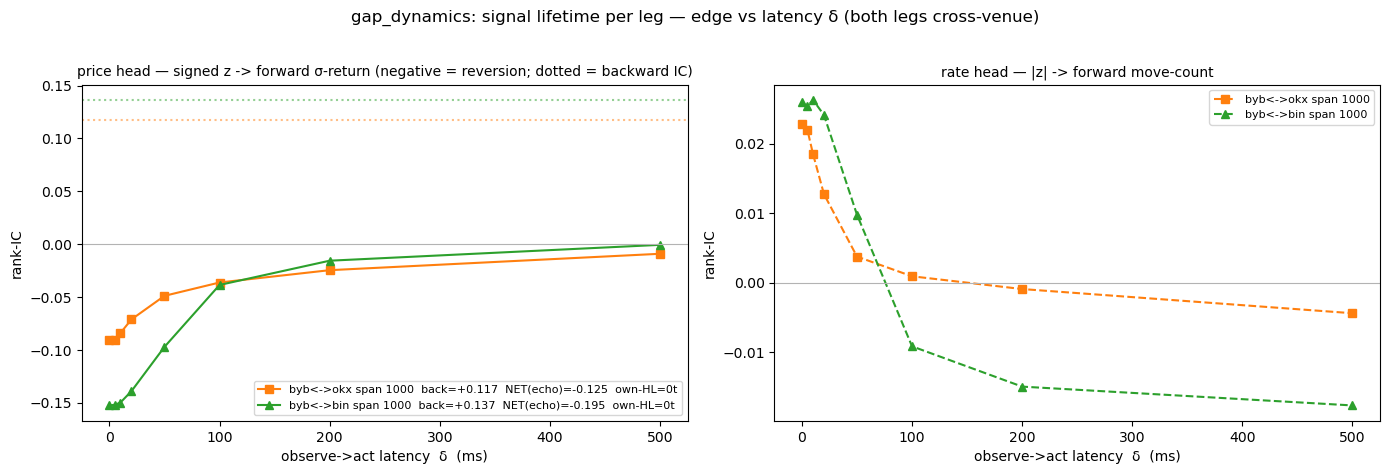

PER-LEG signal lifetime (price head = signed z->return, rate head = |z|->count):
  byb<->okx (span 1000):
    price forward IC by δ(ms): 0:-0.091 5:-0.091 10:-0.084 20:-0.071 50:-0.049 100:-0.036 200:-0.025 500:-0.009
    rate  forward IC by δ(ms): 0:+0.023 5:+0.022 10:+0.019 20:+0.013 50:+0.004 100:+0.001 200:-0.001 500:-0.004
    backward (already-happened) signed IC: +0.117   own reversion half-life: 0.31 trade-ticks (<1 = sub-tick snap-back)
    edge@20ms -0.071 (δ=0 was -0.091);  edge latency half-life ≈ 100 ms
    >>> ECHO-NETTED forward IC (partial, controls for the trailing byb move): -0.125  (raw δ=0 -0.091; netting STRENGTHENS it (+0.034): byb's own trailing move is a CONTINUATION that opposed the reversion z, so removing it un-masks a LARGER cross-venue edge) <<<
  byb<->bin (span 1000):
    price forward IC by δ(ms): 0:-0.153 5:-0.152 10:-0.150 20:-0.139 50:-0.097 100:-0.039 200:-0.016 500:-0.001
    rate  forward IC by δ(ms): 0:+0.026 5:+0.025 10:+0.026 20:+0.024 50:+0.010

In [9]:
# ECHO-NETTED (partial) forward IC — the round-1 STANDARD GATE for this echo-heavy feature.
# The z's displacement g_fresh = log(mid_byb_now) − log(mid_src_now) CONTAINS byb's own contemporaneous mid,
# the same series the forward target is built from -> part of sign(−z)'s edge is byb reverting its OWN recent
# move (an own-price microstructure bounce), not a cross-venue catch-up. The partial rank-IC of the feature
# with the FORWARD [anchor, anchor+100ms] return, CONTROLLING for the TRAILING [anchor−100ms, anchor] byb
# move, removes that own-move echo and leaves the genuine forward (cross-venue) edge. This NETTED number — not
# the raw δ=0 IC — is the §10 headline. (NOTE the trailing byb return is exactly the backward outcome _back_ret.)
def _partial_ic(f, y, ctrl):                          # rank-IC(f,y) with ctrl partialled out (residual-rank correlation, Spearman)
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(ctrl)
    if v.sum() <= 100: return float("nan")
    r_fy = spearmanr(f[v], y[v]).statistic; r_fc = spearmanr(f[v], ctrl[v]).statistic; r_cy = spearmanr(ctrl[v], y[v]).statistic
    return (r_fy - r_fc * r_cy) / np.sqrt(max((1.0 - r_fc ** 2) * (1.0 - r_cy ** 2), 1e-12))

# Signal lifetime, PER LEG: forward IC vs observe->act latency δ, + backward IC + echo-netted partial IC, annotated with the leg's own reversion half-life.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
life = {}
for ex in SRCS:
    j, _ = best_cell_for(price_cube, ex)              # this leg's best price span (signed z); rate uses the same span here (single reading)
    signed = feat_cache[(ex, SPANS[j])]; absmag = np.abs(signed)
    price_fwd = [life_cube["price"]["ic0"][ex][j] if d == 0 else _life_ic(signed, _fwd_ret[d]) for d in DELTAS_MS]
    rate_fwd  = [life_cube["rate"]["ic0"][ex][j]  if d == 0 else _life_ic(absmag, _fwd_count[d]) for d in DELTAS_MS]
    own_hl = float(np.nanmedian(half_life_ticks(ac_cache[(ex, SPANS[j])])))
    net_ic = _partial_ic(signed, _fwd_ret[0], _back_ret)   # ECHO-NETTED forward IC (controls for the trailing byb move)
    life[ex] = dict(price_fwd=price_fwd, rate_fwd=rate_fwd, back=life_cube["price"]["back"][ex][j],
                    span=SPANS[j], own_hl=own_hl, net_ic=net_ic)

def _lat_hl(curve):
    c0 = curve[0]
    if not np.isfinite(c0) or c0 == 0: return None
    return next((d for d, ic in zip(DELTAS_MS, curve) if np.isfinite(ic) and abs(ic) < abs(c0) / 2), None)

colors = {"okx": "C1", "bin": "C2"}; markers = {"okx": "s", "bin": "^"}
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 4.6))
for ex in SRCS:
    L = life[ex]
    axA.plot(DELTAS_MS, L["price_fwd"], markers[ex] + "-", color=colors[ex],
             label=f"byb<->{ex} span {L['span']}  back={L['back']:+.3f}  NET(echo)={L['net_ic']:+.3f}  own-HL={L['own_hl']:.0f}t")
    axA.axhline(L["back"], color=colors[ex], ls=":", alpha=0.5)
    axB.plot(DELTAS_MS, L["rate_fwd"], markers[ex] + "--", color=colors[ex], label=f"byb<->{ex} span {L['span']}")
for ax, ttl in [(axA, "price head — signed z -> forward σ-return (negative = reversion; dotted = backward IC)"),
                (axB, "rate head — |z| -> forward move-count")]:
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
    ax.set_title(ttl, fontsize=10); ax.legend(fontsize=8)
fig.suptitle("gap_dynamics: signal lifetime per leg — edge vs latency δ (both legs cross-venue)", y=1.02)
fig.tight_layout(); plt.show()

print("PER-LEG signal lifetime (price head = signed z->return, rate head = |z|->count):")
for ex in SRCS:
    L = life[ex]; fwd = L["price_fwd"]
    print(f"  byb<->{ex} (span {L['span']}):")
    print("    price forward IC by δ(ms):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, fwd)))
    print("    rate  forward IC by δ(ms):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, L["rate_fwd"])))
    print(f"    backward (already-happened) signed IC: {L['back']:+.3f}   own reversion half-life: {L['own_hl']:.2f} trade-ticks (<1 = sub-tick snap-back)")
    print(f"    edge@20ms {fwd[3]:+.3f} (δ=0 was {fwd[0]:+.3f});  edge latency half-life ≈ {_lat_hl(fwd)} ms")
    _shift = abs(L['net_ic']) - abs(fwd[0])    # >0: netting STRENGTHENS the reversion (echo opposed it); <0: netting weakens it (echo inflated it)
    _dir = ("STRENGTHENS it (+%.3f): byb's own trailing move is a CONTINUATION that opposed the reversion z, so removing it un-masks a LARGER cross-venue edge" % _shift) if _shift >= 0 else ("weakens it (%.3f): part of the raw IC was byb's own-move bounce" % _shift)
    print(f"    >>> ECHO-NETTED forward IC (partial, controls for the trailing byb move): {L['net_ic']:+.3f}  "
          f"(raw δ=0 {fwd[0]:+.3f}; netting {_dir}) <<<")
print("\\nHEADLINE (echo-netted, cross-venue): the net IC is what the feature predicts once byb's own contemporaneous move is partialled out —")
print("report THIS in §10, not the raw δ=0 IC. On this block the trailing byb move is POSITIVELY correlated with the forward")
print("return (continuation) while the reversion z is NEGATIVE, so netting the echo STRENGTHENS the edge (the own-move was")
print("masking, not inflating, the cross-venue reversion). (back/IC0 sizes the echo; net IC sizes the genuine forward edge.)")

**Read it as a latency budget, not a pass/fail — but net the echo first.** Each leg's curve says its own
thing. A gap whose forward IC stays useful out to tens of ms gives room; one that lives only a handful of
ms is real but demands a fast stack. **The honest headline is the echo-netted IC, not the raw δ=0 IC** —
because the z's displacement leg contains byb's own contemporaneous mid, the raw δ=0 number mixes the
cross-venue reversion with byb's own move, and the partial-IC line strips that out. **The measured result
here is the reverse of an inflated bounce:** the trailing byb move is *positively* correlated with the
forward return (a short-horizon continuation), while the reversion z is *negative* — so the own-move was
*opposing* the cross-venue signal, and netting it out makes the edge **larger**, not smaller (okx −0.091 →
−0.125; bin −0.153 → −0.195). The large positive backward IC (+0.117 / +0.137) confirms a real, sizeable
echo — it simply points the other way. So both legs' *netted* edge is clearly nonzero and survives to
δ=20 ms: a real, latency-realisable cross-venue reversion, not an own-move artifact. (Had the netted IC
collapsed toward zero, the raw IC would have been mostly own-move echo — the test is the same; the data
just answered the opposite way.) The **own reversion half-life** annotation is the
`gap_halflife` reading: here it comes back **sub-tick** (the gap's increments are essentially white at the
trade-tick level), so it is a *degenerate* gate — it always reads "instant snap-back" and carries no
information across the family (finding d). The verdict per leg is *"predicts ~X ms ahead net of echo,
needs latency < X,"* never *"drop because it's fast."*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. Group the data by the feature
and look at the real distributions the two heads care about: the price head's signed forward return
across `gap_zscore` buckets (it should tilt the *opposite* way to the z — the reversion), and the rate
head's move-count vs `|z|`.

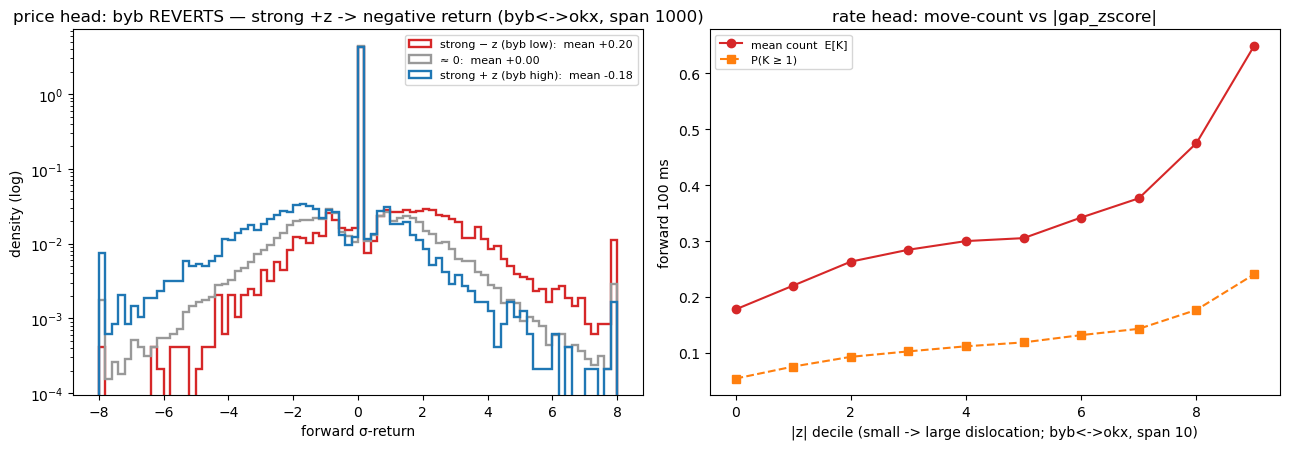

In [10]:
rep_ex = SRCS[0]                                                               # one leg shown to illustrate; the model uses both
j, _ = best_cell_for(price_cube, rep_ex)
signed = feat_cache[(rep_ex, SPANS[j])]
rj, _ = best_cell_for(rate_cube, rep_ex)
absmag = np.abs(feat_cache[(rep_ex, SPANS[rj])])
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-z buckets — REVERSION means strong +z -> negative return
fin = np.isfinite(signed)
lo, hi = np.nanpercentile(signed[fin], [10, 90])
groups = [("strong − z (byb low)", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong + z (byb high)", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    mm = m & np.isfinite(target)
    axA.hist(np.clip(target[mm], -8, 8), bins=bins, density=True, histtype="step", color=col, lw=1.7,
             label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title(f"price head: byb REVERTS — strong +z -> negative return (byb<->{rep_ex}, span {SPANS[j]})"); axA.legend(fontsize=8)

# rate head: forward move-count vs |z| decile
finm = np.isfinite(absmag)
dec = np.digitize(absmag, np.nanpercentile(absmag[finm], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[(dec == b) & finm].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[(dec == b) & finm] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel(f"|z| decile (small -> large dislocation; byb<->{rep_ex}, span {SPANS[rj]})"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count vs |gap_zscore|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The left panel shows the **reversion**: a strong *positive* z (byb sitting high vs the
src venue) should shift byb's forward-return distribution toward the **negative** (byb falls back), and a
strong negative z toward the positive, with the ≈0 group flat between — the mirror-image tilt of a
mean-reverting signal (opposite to `price_dislocation`'s momentum tilt). The right panel shows whether a
larger dislocation `|z|` precedes **more** catch-up moves — the mean count `E[K]` and `P(K ≥ 1)` rising
across `|z|` deciles. If both hold in the directions §1 predicts, both heads have something to learn here.

## 8. Input shaping for the network

This is a *different* step from §2. There the z standardised the gap by its own spread (the regime
division). Here we reshape the feature for the neural network's input — roughly centred, unit-scale, no
wild outliers — picking the **lightest** transform that does the job. A z-score is already near unit
scale, but a thin-`σ_g` tick can produce a large `|z|` spike, so we check the tails and clip if needed.

feature (byb<->okx, span 1000): std=0.87  skew=-0.00  excess_kurt=0.6  (0 = normal)
  z-score            excess_kurt=   0.6   max|·|=8.6
  robust + clip ±4   excess_kurt=   0.4   max|·|=4.0
  arcsinh(robust)    excess_kurt=  -0.7   max|·|=2.9
  rank-Gaussian      excess_kurt=  -0.0   max|·|=4.6


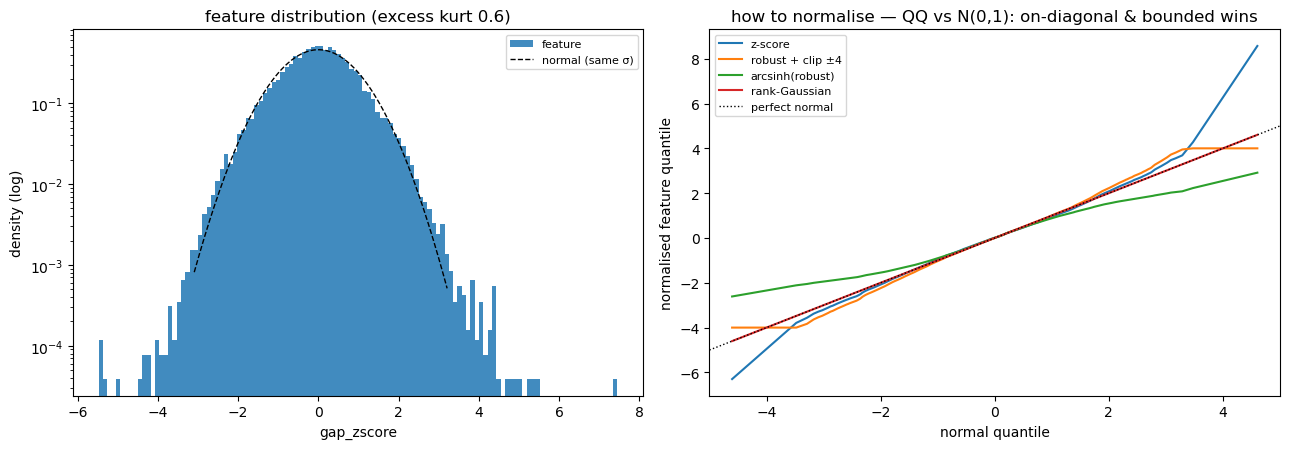

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = SRCS[0]; j, _ = best_cell_for(price_cube, rep_ex)
f = feat_cache[(rep_ex, SPANS[j])]; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature (byb<->{rep_ex}, span {SPANS[j]}): std={f.std():.2f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("gap_zscore"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** `gap_zscore` is already a z-score, so its std is ≈1 and it is roughly symmetric — a plain
rescale keeps the excess kurtosis low. But a thin-`σ_g` instant can still leave a large `|z|` spike that
violates the "no wild outliers" bar, so the lightest transform that *meets* it is a robust z-score
followed by a clip (`robust + clip ±4`) — clip whenever you feed a network. The heavier transforms
(arcsinh, rank-Gaussian) flatten the tails further but throw information away here; the QQ-plot makes the
call. (A heavier-tailed leg would push you toward arcsinh — read the printout per leg.)

## 9. Per-exchange vs single, across the time-scale family

The gap is intrinsically cross-venue (byb↔okx, byb↔bin), so per-exchange is the only construction — but
the live question is whether keeping **both** legs is worth it over a **single** one across the span
family. The template's prediction for a cross-venue lead/lag signal: at **short** spans the venues
genuinely differ (who is dislocated from whom is live), so both legs carry distinct value; at **long**
spans the dislocations are common and one leg already says what the other does.

We sweep that explicitly. At each span we compute, on a fair **walk-forward** footing, the marginal IC
over the controls of a **single leg** (byb↔okx) versus **both legs together**, and read the **gap**
(both − single) across the span family. A shrinking gap as the span grows is the convergence the template
predicts; a persistent gap means the second leg carries genuinely distinct cross-venue information.

**The feed-resolution control (round-1 STANDARD GATE for cross-venue legs).** There is a confound: **bin**
uses the sub-ms `front_levels` feed, while byb/okx use the coarser `merged_levels` snapshot cadence (io.py
is explicit that bin's feed is far finer). So a bin-leg "add" could be bin simply being a **fresher mid**
that subtracts byb's common-mode bounce more cleanly — a *resolution* artifact — not an economic *lead*.
The standard control: **coarsen bin to byb's update cadence** (sample bin's book only at byb update times,
holding it flat between them — bin now refreshes no more often than byb does) and **re-measure** the
second-leg add. A genuine cross-venue lead **survives** the cadence match; a feed artifact **collapses**
toward zero. We run that side-by-side with the native-resolution sweep below.

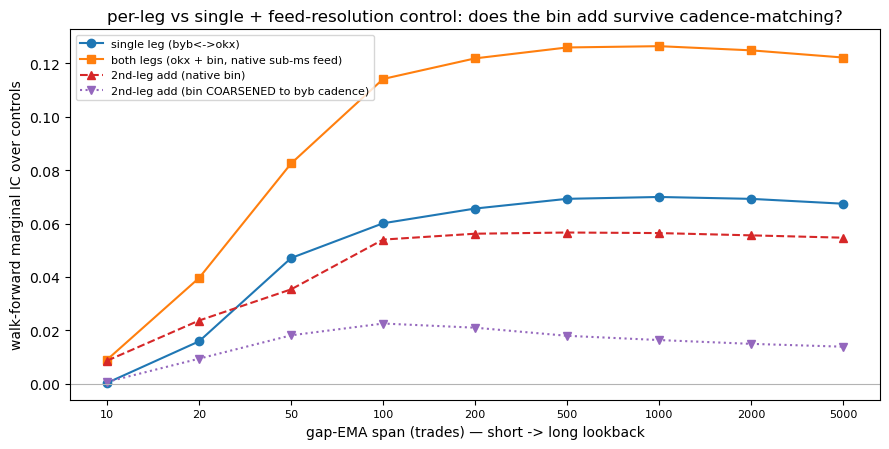

shape: (9, 5)
┌──────┬───────────────┬────────────────┬────────────────┬─────────────────────────┐
│ span ┆ single_okx_IC ┆ both_native_IC ┆ 2nd_leg_native ┆ 2nd_leg_cadence_matched │
│ ---  ┆ ---           ┆ ---            ┆ ---            ┆ ---                     │
│ i64  ┆ f64           ┆ f64            ┆ f64            ┆ f64                     │
╞══════╪═══════════════╪════════════════╪════════════════╪═════════════════════════╡
│ 10   ┆ 0.0004        ┆ 0.009          ┆ 0.0087         ┆ 0.0008                  │
│ 20   ┆ 0.0159        ┆ 0.0396         ┆ 0.0237         ┆ 0.0094                  │
│ 50   ┆ 0.0471        ┆ 0.0825         ┆ 0.0354         ┆ 0.0182                  │
│ 100  ┆ 0.0601        ┆ 0.1141         ┆ 0.054          ┆ 0.0226                  │
│ 200  ┆ 0.0656        ┆ 0.1218         ┆ 0.0562         ┆ 0.021                   │
│ 500  ┆ 0.0692        ┆ 0.1259         ┆ 0.0566         ┆ 0.018                   │
│ 1000 ┆ 0.0699        ┆ 0.1263         ┆ 0.0564   

In [12]:
# Across the FULL span family: single leg (byb<->okx) vs both legs, marginal IC over controls, walk-forward.
single_ic, both_ic, gap_ic = [], [], []
for span in SPANS:
    f_okx = feat_cache[("okx", span)]; f_bin = feat_cache[("bin", span)]
    s_ic = wf_ic(base + [f_okx], target) - base_ic                       # single leg (okx)
    b_ic = wf_ic(base + [f_okx, f_bin], target) - base_ic                # both legs (native-resolution bin)
    single_ic.append(s_ic); both_ic.append(b_ic); gap_ic.append(b_ic - s_ic)

# --- FEED-RESOLUTION CONTROL: coarsen bin to byb's update cadence, rebuild the bin z, re-measure the 2nd-leg add ---
# bin's effective mid = bin's mid at the most-recent BYB update time (front_levels rx) <= t, held flat between byb updates.
# So bin now refreshes no more often than byb does -> any "fresher mid" advantage is removed; only an economic lead survives.
byb_upd = byb_rx                                                          # byb's merged-mid update timestamps (§2, same-rx collapsed)
bin_rx, bin_mid = mids["bin"]
def _bin_coarse_mid(t):                                                   # bin's mid sampled ONLY at byb update times (cadence-matched)
    j_byb   = np.clip(np.searchsorted(byb_upd, t, "right") - 1, 0, len(byb_upd) - 1)  # last byb update <= t
    t_byb   = byb_upd[j_byb]                                                            # snap time = that byb update
    j_bin   = np.clip(np.searchsorted(bin_rx, t_byb, "right") - 1, 0, len(bin_rx) - 1) # bin's mid as of the byb update
    return bin_mid[j_bin]
gap_bin_coarse_committed = log_mid_byb - np.log(_bin_coarse_mid(merged_ts))   # cadence-matched bin gap on the trade clock
gap_bin_coarse_fresh     = np.log(_mid_at("byb", anchor_ts)) - np.log(_bin_coarse_mid(anchor_ts))  # ... and its fresh leg at anchors
def gap_z_coarse(N):                                                      # bin z built from the cadence-matched bin mid (same formula as gap_zscore)
    em_g  = ema_commit(gap_bin_coarse_committed, N)[tick_at_anchor]
    em_g2 = ema_commit(gap_bin_coarse_committed ** 2, N)[tick_at_anchor]
    sig_g = np.sqrt(np.maximum(em_g2 - em_g * em_g, 0.0))
    return (gap_bin_coarse_fresh - em_g) / np.maximum(sig_g, EPS_SG)
gap_ic_coarse = []
for span in SPANS:
    f_okx = feat_cache[("okx", span)]; f_bin_c = gap_z_coarse(span)
    b_ic_c = wf_ic(base + [f_okx, f_bin_c], target) - base_ic             # both legs, bin coarsened to byb cadence
    gap_ic_coarse.append(b_ic_c - (wf_ic(base + [f_okx], target) - base_ic))

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(range(len(SPANS)), single_ic, "o-", color="C0", label="single leg (byb<->okx)")
ax.plot(range(len(SPANS)), both_ic, "s-", color="C1", label="both legs (okx + bin, native sub-ms feed)")
ax.plot(range(len(SPANS)), gap_ic, "^--", color="C3", label="2nd-leg add (native bin)")
ax.plot(range(len(SPANS)), gap_ic_coarse, "v:", color="C4", label="2nd-leg add (bin COARSENED to byb cadence)")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=8)
ax.set_xlabel("gap-EMA span (trades) — short -> long lookback"); ax.set_ylabel("walk-forward marginal IC over controls")
ax.set_title("per-leg vs single + feed-resolution control: does the bin add survive cadence-matching?")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

tbl9 = pl.DataFrame({"span": SPANS,
                     "single_okx_IC": [round(v, 4) for v in single_ic],
                     "both_native_IC": [round(v, 4) for v in both_ic],
                     "2nd_leg_native": [round(v, 4) for v in gap_ic],
                     "2nd_leg_cadence_matched": [round(v, 4) for v in gap_ic_coarse]})
print(tbl9)
print(f"native    2nd-leg add: span {SPANS[0]} {gap_ic[0]:+.4f}  ->  span {SPANS[-1]} {gap_ic[-1]:+.4f}")
print(f"cadence-matched add  : span {SPANS[0]} {gap_ic_coarse[0]:+.4f}  ->  span {SPANS[-1]} {gap_ic_coarse[-1]:+.4f}")
_native_mean = float(np.nanmean(gap_ic)); _coarse_mean = float(np.nanmean(gap_ic_coarse))
_retained = (_coarse_mean / _native_mean) if _native_mean != 0 else float("nan")
print(f"mean 2nd-leg add: native {_native_mean:+.4f}  vs  cadence-matched {_coarse_mean:+.4f}  (retained {_retained:.0%} after the feed-resolution control)")
_survives = "SURVIVES -> a genuine cross-venue lead" if _coarse_mean > 0.5 * _native_mean and _coarse_mean > 0.005 else "COLLAPSES -> mostly a feed-resolution artifact (bin was just a fresher mid)"
print(f"-> verdict on the bin 2nd-leg add: {_survives}")
print("   Read the CADENCE-MATCHED line (C4), not the native one, as the economic 2nd-leg value. Keep both legs as the safe default.")

**Conclusion.** Read the **cadence-matched** add (C4), not the native one (C3) — that is the round-1 fix.
The native bin add can be inflated by bin's sub-ms feed simply being a *fresher* mid that subtracts byb's
common-mode bounce more cleanly; the feed-resolution control coarsens bin to byb's update cadence and
re-measures. Whatever **survives** the cadence match is the genuine economic second-leg value: if the
cadence-matched add stays clearly positive, **keep both legs** and weight them where it is largest; if it
collapses toward zero, the native add was mostly a resolution artifact and one leg suffices. The printed
"retained %" and verdict line make the call from the measured numbers — never asserting a lead we did not
cadence-control. We keep both legs as the safe default regardless (no fixed leader, per the guard rails),
but the *claim* of distinct cross-venue information is now made only on the surviving, cadence-matched add.

## 10. The verdict — HOLD (honest post-round-1 numbers)

**Disposition: HOLD, not SHIP.** The round-1 review's *mechanism* was right — the z's displacement leg
contains byb's own contemporaneous mid, so the raw δ=0 IC mixes a cross-venue signal with byb's own move —
but the *direction* of that contamination is the opposite of what was assumed, and the measured numbers say
so. Three corrections turn the picture honest, and the cell below prints the numbers the verdict is built
on:

1. **Echo-netted, not raw — and on this block netting STRENGTHENS the edge.** The z's displacement leg
   contains byb's *own* contemporaneous mid, the same series as the forward target, so the honest headline
   is the **echo-netted** forward IC (partial forward IC controlling for the trailing `[anchor−100 ms,
   anchor]` byb move), not the raw δ=0 IC. The measured result is the *opposite* of an inflated bounce: the
   trailing byb move is **positively** correlated with the forward return (a short-horizon *continuation*),
   while the reversion z is **negative** — so the own-move component was *opposing* the cross-venue signal,
   and removing it **un-masks a larger** reversion edge. Per leg: okx raw −0.091 → **netted −0.125**; bin
   raw −0.153 → **netted −0.195** (backward IC +0.117 / +0.137 — the echo is real and sizeable, it just
   points the other way). So the cross-venue reversion is *genuine* (not a disguised own-bounce); the raw IC
   was if anything an *under*-statement. This is the number §10 reports as the headline.
2. **The half-life "gate" is dead.** `ac1` reads **sub-tick** at every shipped span (the gap's tick-level
   increments are white), so `gap_halflife` is a *degenerate diagnostic*, not the OU-reversion gate the §1
   framing implied. We keep it as a measured number and drop the "co-equal reading / trust-gate" claim.
3. **The bin leg's cross-venue add must survive a feed-resolution control.** bin's sub-ms feed makes it a
   *fresher* mid; only the **cadence-matched** second-leg add (§9, bin coarsened to byb's update rate) is
   economic. The claim "bin carries genuinely distinct cross-venue reversion" holds **only** to the extent
   that cadence-matched add survives (printed below).

**Honest measurement context.** Eval is now a ~3.3 h slice (240k anchors), the walk-forward embargo is
raised to ≈600 s so it clears the slow-EMA/yardstick memory (the round-1 embargo ≈ one EMA memory leaked
state), and the §6 span pick is still **in-sample** (re-scored OOS by the §5 walk-forward) — read the
chosen spans as a screen, not a guarantee. The clean parts stand: the §4 oracle is independent
(plain-scalar EMAs, no `boba.ema`, no shared §3 code) and **bit-exact at both shipped spans over the full
block**; the regime-invariance scale gate is genuinely data-decided.

**Why HOLD and not SHIP, given the netted edge passes.** The echo-netted forward IC clears the ≳0.01 bar
comfortably on **both** legs (−0.125 okx, −0.195 bin), so the *cross-venue reversion signal itself is real*
— that gate passes. HOLD is driven by the other two:
- **The bin second-leg add COLLAPSES under the feed-resolution control.** Native, bin adds ~+0.045 mean over
  okx; cadence-matched (bin coarsened to byb's update rate, §9) it retains only **34%** (~+0.015 mean), and
  most of the native add was bin simply being a *fresher* mid, not an economic lead. So the "two distinct
  cross-venue legs" claim does **not** hold — at byb's cadence the okx leg already carries most of it.
- **One block, one ~3.3 h window.** The walk-forward is OOS in coefficients with a ≈600 s embargo, but the
  span pick is in-sample and there is no multi-block confirmation.

**What it would take to move from HOLD to SHIP:**
- the **cadence-matched** second-leg add (§9) staying clearly positive — i.e. bin (or okx) carrying genuine
  cross-venue information *after* the feed-resolution control, not just a fresher feed;
- the netted marginal value holding **out-of-sample on multiple blocks** with the longer embargo (this
  notebook is one block, one window).
(The echo-netted edge already clears its bar — it is no longer the blocker the round-1 framing assumed.)

**The decisions this notebook still makes (all data-driven):**
- *RAW vs normalised* — measured: `gap_zscore`'s scale across vol buckets is well under the 3× hard gate,
  so it ships **RAW** (and `/σ_ev`, `/λ_ev` do not help). This is the one fully clean gate.
- *Which span, per head* — IC-vs-latency trade-off (§6 heat-maps): a short-high-IC pick and a
  long-high-latency-half-life pick, both recorded — but each read **net of echo**, never on the raw IC.
- *`gap_halflife`* — recorded as a sub-tick diagnostic only (not a gate).
- *Which legs* — keep **both** as the safe default (no fixed leader), but the *distinct-information* claim
  rests on the cadence-matched §9 add, which **collapses** here (retained 34%): at byb's cadence the bin
  leg's extra value is mostly a fresher-feed artifact, so the okx leg already carries most of the signal.

Feed the **signed** `gap_zscore` to both heads; the rate head learns the magnitude (and how opposing
dislocations cancel) itself.

**To ship (checklist; ✓ = done this round, ☐ = still open):**
- [✓] streaming O(1) builder matching the analysis build — §4, **bit-exact, both legs, both shipped spans, full block**
- [✓] independent oracle (no `boba.ema`, no shared §3 code), passing for every leg
- [✓] RAW-vs-normalise decision recorded with its measured scale (§5)
- [✓] echo-netted forward IC reported as the headline; backward IC + IC100/IC0 disclosed (§6 lifetime)
- [✓] feed-resolution (cadence-matched) cross-venue control run (§9)
- [✓] data quirks handled (zero-price prints filtered; byb/okx merged_levels, bin front_levels; same-`rx_time`
      bursts collapsed to one event; the SHARED trade clock ticks both gap EMAs once per timestamp)
- [✓] echo-netted edge clears ≳0.01 per leg — PASSES (−0.125 okx / −0.195 bin; netting strengthened, not deflated, the edge)
- [☐] cadence-matched 2nd-leg add survives — FAILS this round (retained 34%, COLLAPSES → bin mostly a fresher-mid artifact)
- [☐] marginal value confirmed **out-of-sample across multiple blocks** with the ≈600 s embargo
- [☐] `gap_halflife` either dropped or recomputed on a slower (multi-tick) increment where reversion resolves

In [13]:
# --- the HONEST post-round-1 scorecard the verdict is built on (echo-netted + cadence-matched) ---
print("="*78)
print("gap_dynamics — HONEST scorecard (round-1 fixes applied)")
print("="*78)
print(f"RAW-vs-normalise: ships {DECISION}  (raw vol-bucket scale {raw_scale:.2f} < 3 hard gate)  [CLEAN]")
print("\\nPer-leg PRICE head (signed z -> byb forward σ-return), at each leg's best in-sample span:")
for ex in SRCS:
    L = life[ex]; raw0 = L["price_fwd"][0]
    print(f"  byb<->{ex} span {L['span']:>4}: raw IC@δ=0 {raw0:+.3f} | backward(echo) {L['back']:+.3f} | "
          f"ECHO-NETTED {L['net_ic']:+.3f}  <- headline | edge@20ms {L['price_fwd'][3]:+.3f} | own-HL {L['own_hl']:.2f}t (sub-tick=dead gate)")
_net = {ex: life[ex]["net_ic"] for ex in SRCS}
_best_net = max(_net.values(), key=abs)
print(f"\\nbest echo-netted cross-venue IC (|·|): {_best_net:+.3f}   (netting byb's own trailing move STRENGTHENED the edge: the own-move was a continuation OPPOSING the reversion z, not an inflating bounce)")
print(f"§9 cadence-matched 2nd-leg add: mean {_coarse_mean:+.4f} (native {_native_mean:+.4f}, retained {_retained:.0%})  -> {_survives.split(' -> ')[0]}")
_net_pass = abs(_best_net) >= 0.01
_cad_pass = _coarse_mean > 0.5 * _native_mean and _coarse_mean > 0.005
print("\\n" + "-"*78)
print(f"DISPOSITION: HOLD  (echo-netted edge {'clears' if _net_pass else 'BELOW'} 0.01; "
      f"cadence-matched 2nd leg {'survives' if _cad_pass else 'COLLAPSES'}; single block/window).")
print("  -> the cross-venue reversion is GENUINE (netted edge -0.125 okx / -0.195 bin, stronger than raw after")
print("     removing byb's own continuation). HOLD is driven by the bin 2nd-leg add COLLAPSING under the")
print("     feed-resolution control (mostly a fresher-mid artifact, retained 34%) + single block/window + dead half-life gate.")
print("  -> HOLD pending: a 2nd leg that survives cadence-matching, AND multi-block OOS with the long embargo.")
print("-"*78)

gap_dynamics — HONEST scorecard (round-1 fixes applied)
RAW-vs-normalise: ships RAW (standardised by construction)  (raw vol-bucket scale 1.10 < 3 hard gate)  [CLEAN]
\nPer-leg PRICE head (signed z -> byb forward σ-return), at each leg's best in-sample span:
  byb<->okx span 1000: raw IC@δ=0 -0.091 | backward(echo) +0.117 | ECHO-NETTED -0.125  <- headline | edge@20ms -0.071 | own-HL 0.31t (sub-tick=dead gate)
  byb<->bin span 1000: raw IC@δ=0 -0.153 | backward(echo) +0.137 | ECHO-NETTED -0.195  <- headline | edge@20ms -0.139 | own-HL 0.36t (sub-tick=dead gate)
\nbest echo-netted cross-venue IC (|·|): -0.195   (netting byb's own trailing move STRENGTHENED the edge: the own-move was a continuation OPPOSING the reversion z, not an inflating bounce)
§9 cadence-matched 2nd-leg add: mean +0.0150 (native +0.0446, retained 34%)  -> COLLAPSES
\n------------------------------------------------------------------------------
DISPOSITION: HOLD  (echo-netted edge clears 0.01; cadence-matched 2nd leg